## Data Preprocessing and Filtering

In [1]:
import pandas as pd
import scanpy as sc

df = pd.read_csv(r"C:\Users\Lenovo\Desktop\M2R Project\intestine_data.txt", sep="\t") 
df_T = df.T
from IPython.display import display
display(df_T)
#convert to AnnData type for scanpy analysis
adata = sc.AnnData(df_T)

,0610005C13Rik,0610007N19Rik,0610007P14Rik,0610008F07Rik,0610009B14Rik,0610009B22Rik,0610009D07Rik,0610009L18Rik,0610009O20Rik,0610010B08Rik,...,Zxda,Zxdb,Zxdc,Zyg11a,Zyg11b,Zyx,Zzef1,Zzz3,a,l7Rn6
Enterocyte_Progenitor_Late.49,0.000000,72.550858,117.981396,0.0,0.0,105.891253,99.071172,0.00000,98.621167,0.000000,...,0.000000,0.0,0.000000,0.0,6.950082,3.890046,5.730068,0.000000,0.0,9.690115
Enterocyte.111,53.040048,0.000000,166.610152,0.0,0.0,25.920024,83.000076,0.00000,20.990019,1.370001,...,0.000000,0.0,0.360000,0.0,0.000000,0.000000,12.600011,0.000000,0.0,25.480023
Stem.391,0.000000,71.430681,8.030077,0.0,0.0,33.420319,71.480682,0.00000,29.010277,0.000000,...,0.000000,0.0,0.000000,0.0,0.400004,29.830285,14.200135,34.870333,0.0,82.990792
TA.118,0.000000,0.000000,329.554515,0.0,0.0,101.441390,101.861396,0.00000,98.081344,0.360005,...,0.000000,0.0,19.900273,0.0,8.930122,1.010014,10.870149,36.740503,0.0,97.061330
Stem.392,41.130909,29.110643,182.374029,0.0,0.0,28.920639,95.712114,0.00000,48.061062,0.000000,...,0.000000,0.0,0.000000,0.0,1.270028,0.000000,0.000000,8.120179,0.0,60.321332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Stem.389,43.721059,18.350444,16.590402,0.0,0.0,55.991356,84.862055,0.00000,3.180077,0.180004,...,0.000000,0.0,0.000000,0.0,2.550062,6.260152,0.000000,2.980072,0.0,0.000000
Enterocyte_Progenitor_Late.48,52.800937,8.350148,85.251513,0.0,0.0,122.132168,64.491145,0.00000,20.040356,0.950017,...,0.000000,0.0,0.000000,0.0,1.470026,0.000000,9.740173,3.660065,0.0,24.480435
Stem.390,0.000000,43.101525,58.782079,0.0,0.0,0.000000,211.227471,0.00000,30.561081,0.310011,...,0.350012,0.0,0.000000,0.0,1.100039,10.040355,1.350048,0.000000,0.0,139.324928
Stem.31,59.239988,37.899992,0.000000,0.0,0.0,36.659992,0.000000,48.16999,88.229981,0.000000,...,1.290000,0.0,0.000000,0.0,0.950000,45.369990,0.000000,10.819998,0.0,91.239981


In [2]:
#Data Filtering
sc.pp.filter_cells(adata, min_genes=300)   # every cell must express at least 300 genes, or considered a bad sample
sc.pp.filter_genes(adata, min_cells=5)     # every gene must be expressed in at least 3 cells, or considered insignificant


print(adata.shape)

(1522, 17544)


In [3]:
sc.pp.normalize_total(adata, target_sum=1e4)

#take log(1+x) of the raw data to avoid data explosion
sc.pp.log1p(adata)

In [4]:
# calculate cell cycle score
s_genes = [
    "Mcm5", "Pcna", "Tyms", "Fen1", "Mcm2", "Mcm4", "Rrm1", "Ung",
    "Gins2", "Mcm6", "Cdca7", "Dtl", "Prim1", "Uhrf1", "Mlf1ip",
    "Helq", "Rfc2", "Rpa2", "Nasp", "Rad51ap1", "Gmnn", "Wdr76",
    "Slbp", "Ccne2", "Ubr7", "Pold3", "Msh2", "Atad2", "Rad51",
    "Rrm2", "Cdc45", "Cdc6", "Exo1", "Tipin", "Dscc1", "Blm",
    "Casp8ap2", "Uhrf1"
]

# G2/M phase markers
g2m_genes = [
    "Hmgb2", "Ckap2", "Top2a", "Nusap1", "Birc5", "Cdca3", "Cdc20",
    "Cdca8", "Cdk1", "Bub1", "Bub1b", "Cdc25c", "Kif2c", "Ckap2l",
    "Aurkb", "Ccnb2", "Tpx2", "Ncapg", "Cks2", "Cks1b", "Nuf2",
    "Cenpf", "Ttk", "Cenpe", "Kif20b", "Cdca2", "Ndc80", "Fzr1",
    "Spc25", "Ube2c", "Aurka", "Spc24", "Anp32e", "Tubb4b"
]
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

# remove the effect of cell cycle
sc.pp.regress_out(adata, ['S_score', 'G2M_score'])


In [5]:
#select highly-variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=5000, flavor='seurat', subset=False)

#perform Principle Component Analysis on the subsets which are considered highly-variable
adata_hvg = adata[:, adata.var['highly_variable']]
sc.pp.scale(adata_hvg, max_value=10)

sc.tl.pca(adata_hvg, n_comps=200, svd_solver='arpack')

total_explained = adata_hvg.uns['pca']['variance_ratio'].sum() #check what proportion of the variance is explained by PCA
print(total_explained)
#using these principle components to construct a KNN graph, with each cell identified as a node and connected to 40 nearest neighbours
sc.pp.neighbors(adata_hvg, n_neighbors=300, n_pcs=30)

D:\Anaconda\Lib\site-packages\scanpy\preprocessing\_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


0.44696875306058387


## Leiden Clustering

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27200\3480247604.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_hvg, resolution=1.0)


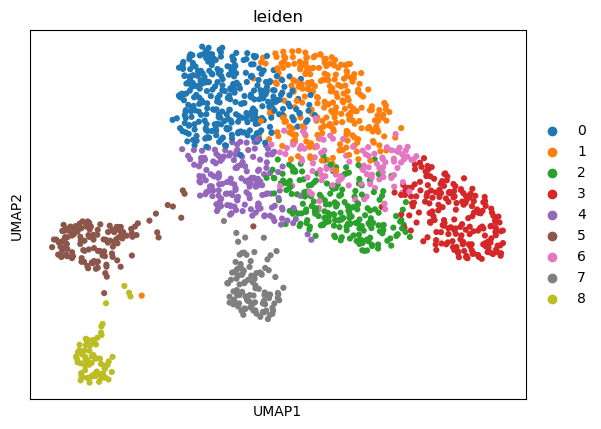

In [6]:
#Use Leiden Clustering Algorithm
sc.tl.leiden(adata_hvg, resolution=1.0)

#visualize by using UMAP(Uniform Manifold Approximation and Projection)
sc.tl.umap(adata_hvg)
sc.pl.umap(adata_hvg, color='leiden')

D:\Anaconda\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
D:\Anaconda\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
D:\Anaconda\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
D:\Anaconda\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
D:\Anaconda\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
D:\Anaconda\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.sta

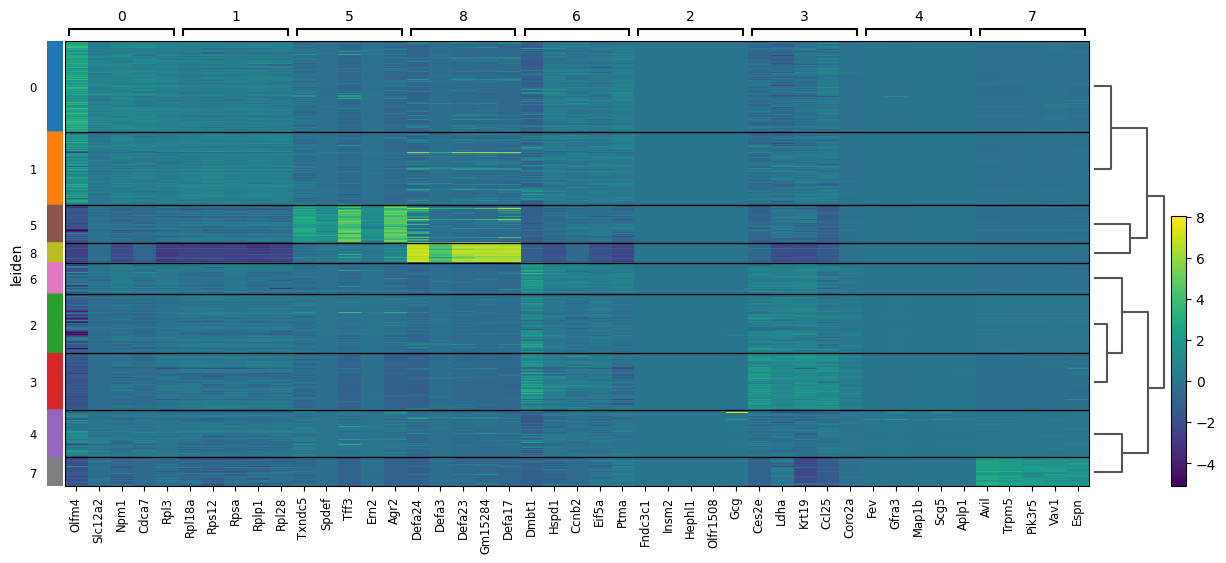

In [8]:
#parallel the cluster results from adata_hvg to adata
adata.obs['leiden'] = adata_hvg.obs['leiden']


#identify the marker genes within each cluster
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')

sc.pl.rank_genes_groups_heatmap(adata, n_genes=5, groupby='leiden', show_gene_labels=True)


## Label the Clusters by combining marker genes overlap and Enrichment Analysis

In [9]:
#collect the marker genes from each cluster into a panda DataFrame
clusters = list(adata.obs['leiden'].cat.categories)
names_dict = adata.uns['rank_genes_groups']['names'][:200]
marker_lists = [list(names_dict[cl]) for cl in clusters]
marker_df = pd.DataFrame({    
    'cluster': clusters,
    'marker_genes': marker_lists
})
display(marker_df)

,cluster,marker_genes
0,0,"[Olfm4, Slc12a2, Npm1, Cdca7, Rpl3, Eef1a1, Rp..."
1,1,"[Rpl18a, Rps12, Rpsa, Rplp1, Rpl28, Rpl32, Rpl..."
2,2,"[Fndc3c1, Insm2, Hephl1, Olfr1508, Gcg, Obox2,..."
3,3,"[Ces2e, Ldha, Krt19, Ccl25, Coro2a, Apol10a, A..."
4,4,"[Fev, Gfra3, Map1b, Scg5, Aplp1, Chgb, Syt13, ..."
5,5,"[Txndc5, Spdef, Tff3, Ern2, Agr2, Fcgbp, Gcnt3..."
6,6,"[Dmbt1, Hspd1, Ccnb2, Eif5a, Ptma, Atp5b, Gsdm..."
7,7,"[Avil, Trpm5, Pik3r5, Vav1, Espn, Ltc4s, Cd24a..."
8,8,"[Defa24, Defa3, Defa23, Gm15284, Defa17, Defa2..."


In [10]:
#enrichment analysis, helps with labeling the clusters with cell types

from gseapy import enrichr

results = []

for i, row in marker_df.iterrows():
    cluster = row['cluster']
    genes = row['marker_genes']
    enr = enrichr(
            gene_list=genes,
            gene_sets='GO_Biological_Process_2021',
            organism='Mouse',
            outdir=None,
            no_plot=True)
    top_results = enr.results.head(10).copy()
    top_results['cluster'] = cluster
    results.append(top_results)

In [11]:
enrichment_df = pd.concat(results, ignore_index=True)
display(enrichment_df[['cluster', 'Term', 'Adjusted P-value', 'Overlap']])
#here Overlap means how many marker genes in each cluster overlap with the known functional gene sets

,cluster,Term,Adjusted P-value,Overlap
0,0,cytoplasmic translation (GO:0002181),5.865728e-76,51/93
1,0,SRP-dependent cotranslational protein targetin...,7.124124e-73,49/90
2,0,cotranslational protein targeting to membrane ...,9.439538e-72,49/94
3,0,"nuclear-transcribed mRNA catabolic process, no...",1.092169e-70,51/113
4,0,protein targeting to ER (GO:0045047),2.501712e-69,49/103
...,...,...,...,...
85,8,defense response to Gram-negative bacterium (G...,1.442442e-01,5/73
86,8,proline transport (GO:0015824),2.124716e-01,2/6
87,8,cellular response to lipid (GO:0071396),2.124716e-01,8/219
88,8,defense response to bacterium (GO:0042742),2.124716e-01,7/176


In [12]:
#This is a choice of reference for classification
df3 = pd.read_csv(r"C:\Users\Lenovo\Desktop\M2R Project\CellMarker.csv", sep=",")
df3 = df3[['Cell Type', 'Cell Marker']]
df3['marker_list'] = df3['Cell Marker'].str.split(',') .apply(lambda genes: [g.strip() for g in genes])

intestine_cell_markers = {
    ct: set(genes)
    for ct, genes in zip(df3['Cell Type'], df3['marker_list'])
}


print(intestine_cell_markers)

{'Cancer stem cell': {'CD166'}, 'Intestinal epithelial stem cell': {'Lgr5'}, 'Intestinal stem cell': {'Lgr5', 'Dclk1', 'Hesx1', 'Side population', 'Musashi-1'}, 'Paneth cell': {'Defa17', 'Gm15284', 'Defa-rs1', 'Defa21', 'AY761184', 'Ang4', 'Defa3', 'Mptx2', 'Defa24', 'Defa26', 'Lyz1', 'Defa22', 'Gm14851', 'Gm15292'}, 'Goblet cell': {'Kdelr3', 'Tff3', 'Galnt7', 'Rep15', 'Smim14', 'Tspan13', 'Spink4', 'Sep15', 'Ddost', 'Hgfac', 'Agr2', 'Zg16', 'Ramp1', 'Calr', 'Sec61b', 'Txndc5', 'Pdia5', 'Serp1', 'Pdia3', 'Gale', 'Bace2', 'Manf', 'Foxa3', 'Tmed9', 'Pla2g10', 'Smim6', 'Pdia6', 'Guk1', 'Vimp', 'Cmtm7', 'Klf4', 'Slc50a1', 'Spdef', 'Dnajc10', 'Guca2a', 'Tram1', 'Ssr4', 'Klk1', 'Tpd52', 'Tmed3', 'S100a6', 'Tpsg1', 'Sdf2l1', 'Creb3l1', 'Cmpk1', 'Arf4', 'Slc12a8', 'Lrrc26', 'Galnt12', 'Tmsb10', 'Krtcap2', 'AW112010', 'Ern2', 'Stard3nl', 'Ssr2', 'Ttc39a', 'Ccl9', 'Creb3l4', 'Gcnt3', 'Uap1', 'Qsox1', 'Scin', 'Creld2', 'Clca1', 'Xbp1', 'Muc2', 'Wars', 'Tsta3', 'Atoh1', 'Kdelr2', 'Oit1', 'Hpd', 'S

In [13]:
#a function that could auto-classify cell types according to marker genes
def annotate_cluster(top_genes):
    best_type, best_match = 'Unknown', 0
    for cell_type, markers in intestine_cell_markers.items():
        matches = len(set(top_genes) & set(markers))
        if matches > best_match:
            best_match = matches
            best_type = cell_type
    return best_type

{'0': 'Intestinal epithelial stem cell', '1': 'Unknown', '2': 'DCLK1+ progenitor cell', '3': 'Enterocyte', '4': 'Enteroendocrine cell', '5': 'Goblet cell', '6': 'Enterocyte', '7': 'Brush cell (Tuft cell)', '8': 'Goblet cell'}


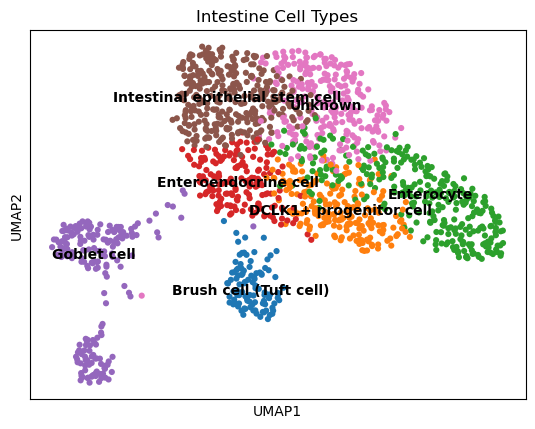

In [14]:
#apply the function to marker_genes for each cluster
marker_df['predicted_type'] = marker_df['marker_genes'].apply(lambda genes: annotate_cluster(genes))
#construct a dictionary to build a projection map from the cluster to cell type
cluster_to_type = dict(zip(marker_df['cluster'], marker_df['predicted_type']))

print(cluster_to_type)

adata_hvg.obs['cell_type'] = (adata_hvg.obs['leiden'].map(cluster_to_type).astype('category'))

sc.pl.umap(
    adata_hvg,
    color='cell_type',
    legend_loc='on data',
    title='Intestine Cell Types')

In [15]:
cell_type_to_terms = {
    'Intestinal epithelial stem cell': [
        'wnt signaling', 'notch signaling', 'stem cell population maintenance', 'peptide biosynthetic process'
    ],
    'Goblet cell': [
        'protein glycosylation', 'o-glycan processing', 'mucin secretion', 'er stress', 'peptide biosynthetic'
    ],
    'Paneth cell': [
        'defense response', 'response to bacterium', 'antimicrobial humoral response', 'innate immune response in mucosa'
    ],
    'Enterocyte': [
        'lipid metabolism', 'intestinal absorption', 'carbohydrate catabolic process', 'brush border assembly',
        'glycolytic process', 'gluconeogenesis', 'hexose biosynthetic process', 'transepithelial transport', 'cellular response to lipid'
    ],
    'Enteroendocrine cell': [
        'hormone secretion', 'peptide hormone secretion', 'neuropeptide signaling'
    ],
    'Brush cell (Tuft cell)': [
        'type 2 immune response', 'interleukin-25 production', 'sensory perception', 'chemosensory perception', 'trpm5', 'taste receptor activity', 
        'leukotriene biosynthetic process', 'leukotriene metabolic process', 'cellular response to cytokine stimulus'
    ],
    'DCLK1+ progenitor cell': ['leukotriene biosynthetic process', 'mucosal immune response',
    ]
}


go_term_to_cell_type = {}
for ct, terms in cell_type_to_terms.items():
    for term in terms:
        go_term_to_cell_type[term.lower()] = ct

In [16]:
from collections import defaultdict
import numpy as np

# 进行打分聚合
cluster_scores = defaultdict(lambda: defaultdict(float))

for _, row in enrichment_df.iterrows():
    term = row['Term'].lower()
    pval = row['Adjusted P-value']
    for keyword, cell_type in go_term_to_cell_type.items():
        if keyword in term:
            score = -np.log10(pval + 1e-10)
            cluster_scores[str(row['cluster'])][cell_type] += score


# 为每个 cluster 选出得分最高的 cell type
cluster_go_type = {}
for clust, score_dict in cluster_scores.items():
    if score_dict:
        top_label = max(score_dict.items(), key=lambda x: x[1])[0]
        cluster_go_type[clust] = top_label

cluster_go_type

{'0': 'Intestinal epithelial stem cell',
 '1': 'Intestinal epithelial stem cell',
 '3': 'Enterocyte',
 '4': 'Enteroendocrine cell',
 '5': 'Goblet cell',
 '7': 'Brush cell (Tuft cell)',
 '8': 'Paneth cell'}

In [17]:
refined_mapping = {}

for clust in cluster_to_type:
    overlap_label = cluster_to_type[clust]
    enrichment_label = cluster_go_type.get(clust, None)
    enrichment_scores = cluster_scores.get(clust, {})
    overlap_score = enrichment_scores.get(overlap_label, 0)
    enrichment_score = enrichment_scores.get(enrichment_label, 0)

    if overlap_label.lower() == 'unknown':
        refined_mapping[clust] = enrichment_label
    elif overlap_label != enrichment_label and enrichment_score > overlap_score:
        refined_mapping[clust] = enrichment_label
    else:
        refined_mapping[clust] = overlap_label

refined_mapping

{'0': 'Intestinal epithelial stem cell',
 '1': 'Intestinal epithelial stem cell',
 '2': 'DCLK1+ progenitor cell',
 '3': 'Enterocyte',
 '4': 'Enteroendocrine cell',
 '5': 'Goblet cell',
 '6': 'Enterocyte',
 '7': 'Brush cell (Tuft cell)',
 '8': 'Paneth cell'}

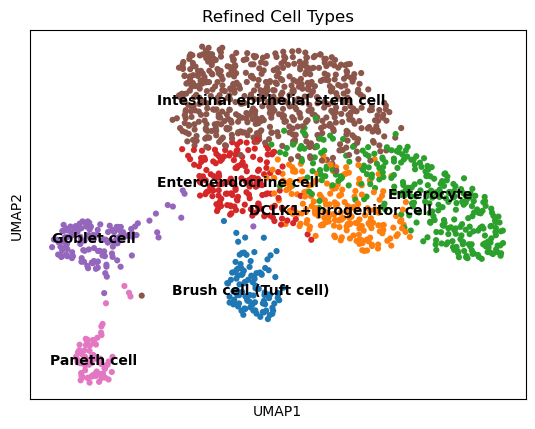

In [18]:
adata_hvg.obs['refined_type'] = adata_hvg.obs['leiden'].map(refined_mapping).astype('category')
sc.pl.umap(adata_hvg, color='refined_type', legend_loc='on data', title='Refined Cell Types')

## Identifying Transcription Factors and their Target genes, construct Regulatory Networks

In [18]:
tf_df = pd.read_csv(r"C:\Users\Lenovo\Desktop\M2R Project\Mus_musculus_TF.txt", sep="\t")
tf_genes = set(tf_df['Symbol'].dropna().str.strip())

def extract_tfs(gene_list):
    return [gene for gene in gene_list if gene in tf_genes]

marker_df['TFs'] = marker_df['marker_genes'].apply(extract_tfs)
display(marker_df)

,cluster,marker_genes,predicted_type,TFs
0,0,"[Olfm4, Slc12a2, Npm1, Cdca7, Rpl3, Eef1a1, Rp...",Intestinal epithelial stem cell,"[Vdr, Ets2, Tgif1, Jun, Hmgb3, Arid5b, Nfib, E..."
1,1,"[Rpl18a, Rps12, Rpsa, Rplp1, Rpl28, Rpl32, Rpl...",Unknown,"[Myc, Nme2, Zfp36l2, Hmga1, Mlxip]"
2,2,"[Fndc3c1, Insm2, Hephl1, Olfr1508, Gcg, Obox2,...",DCLK1+ progenitor cell,"[Insm2, Prdm13, Zkscan16, Smarca1, Zbtb7c, Lyl..."
3,3,"[Ces2e, Ldha, Krt19, Ccl25, Coro2a, Apol10a, A...",Enterocyte,"[Isl2, Barhl1, Hoxb2, Gm4981, Hoxd4, Purg, Zfp..."
4,4,"[Fev, Gfra3, Map1b, Scg5, Aplp1, Chgb, Syt13, ...",Enteroendocrine cell,"[Fev, Neurod1, Myt1, Pax6, Rfx6, Isl1, Glis3, ..."
5,5,"[Txndc5, Spdef, Tff3, Ern2, Agr2, Fcgbp, Gcnt3...",Goblet cell,"[Spdef, Atoh1, Creb3l4, Foxa3, Xbp1, Creb3l1, ..."
6,6,"[Dmbt1, Hspd1, Ccnb2, Eif5a, Ptma, Atp5b, Gsdm...",Enterocyte,"[Cenpa, Hmgb1, Hmgb2, Phb, Cnbp, Lyar, Sub1]"
7,7,"[Avil, Trpm5, Pik3r5, Vav1, Espn, Ltc4s, Cd24a...",Brush cell (Tuft cell),"[Spib, Pou2f3, Sox9, Jarid2, Runx1, Hmx3, Ehf,..."
8,8,"[Defa24, Defa3, Defa23, Gm15284, Defa17, Defa2...",Goblet cell,"[Bhlha15, Klf15, Atoh1, Spdef, Creb3l4, Mkx, Z..."


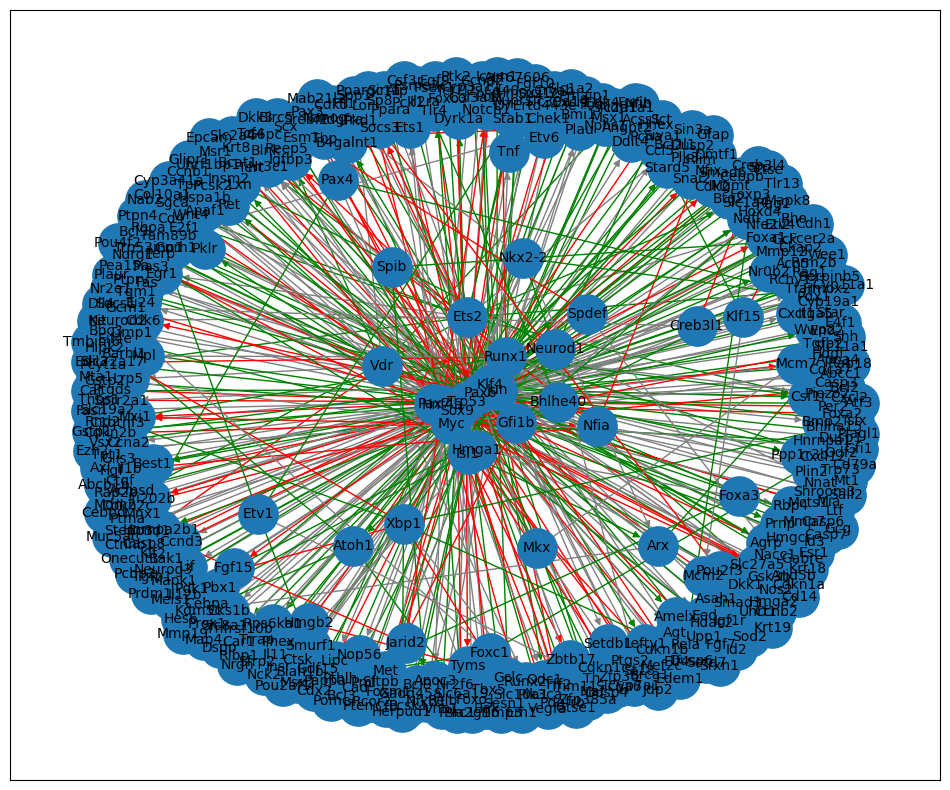

In [19]:
trrust_df = pd.read_csv(r"C:\Users\Lenovo\Desktop\M2R Project\trrust_rawdata.mouse.tsv", sep="\t", header=None)
trrust_df.columns = ['TF', 'Target', 'Regulation', 'PMID']
trrust_df = trrust_df[trrust_df['Target'].isin(adata.var_names)]

#expand the extracted TFs row-wise so to compare with TRRUST DATA SET
records = []
for _, row in marker_df.iterrows():
    for tf in row['TFs']:
        records.append({'cluster': row['cluster'], 'TF': tf})
cluster_tf_df = pd.DataFrame(records)

#select target genes from the trrust data base
reg_df = pd.merge(cluster_tf_df, trrust_df, on='TF', how='inner')


import matplotlib.pyplot as plt
import networkx as nx
G = nx.DiGraph()
for _, row in reg_df.iterrows():
    G.add_edge(row['TF'], row['Target'], cluster=row['cluster'], regulation=row['Regulation'])

edge_colors = []
for u, v in G.edges():
    reg_type = G[u][v].get('regulation', 'Unknown')
    if reg_type == 'Activation':
        edge_colors.append('green')
    elif reg_type == 'Repression':
        edge_colors.append('red')
    else:
        edge_colors.append('gray')

#visualization
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.6)
nx.draw_networkx(G, pos,
                 with_labels=True,
                 node_size=800,
                 font_size=10,
                 edge_color=edge_colors,
                 arrows=True)

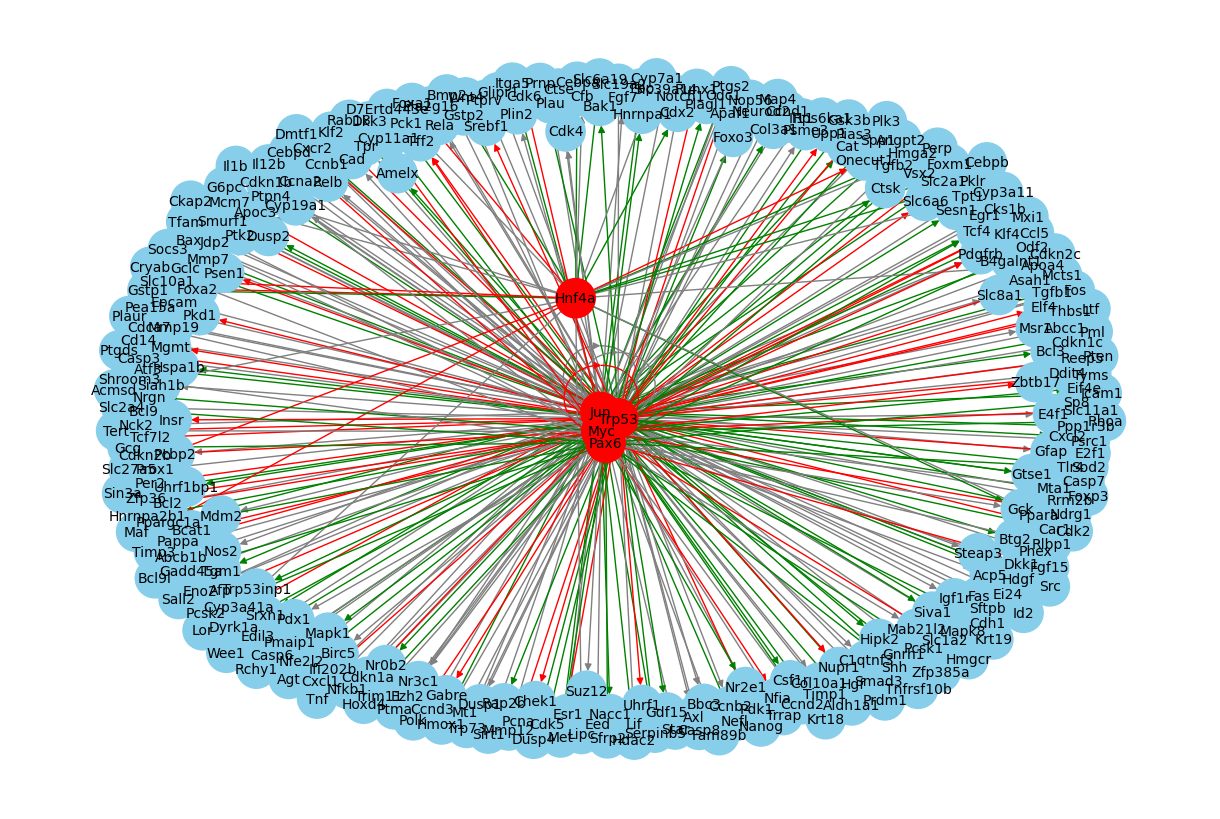

In [20]:
#calculate centrality and list the most important transcription factors
centrality = nx.out_degree_centrality(G)
top_hubs = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]
core_TFs = [tf for tf, score in top_hubs]


sub_edges = [(u, v) for u, v in G.edges() if u in core_TFs]
subG = G.edge_subgraph(sub_edges).copy()

node_colors = ['red' if node in core_TFs else 'skyblue' for node in subG.nodes()]

#plot the subgraph
edge_colors = []
for u, v in subG.edges():
    reg = subG[u][v].get('regulation', 'Unknown')
    if reg == 'Activation':
        edge_colors.append('green')
    elif reg == 'Repression':
        edge_colors.append('red')
    else:
        edge_colors.append('gray')

# Step 5: 绘图
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subG, k=0.5)
nx.draw(subG, pos,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=800,
        font_size=10,
        arrows=True)

## PAGA and Pseudo-time Analysis

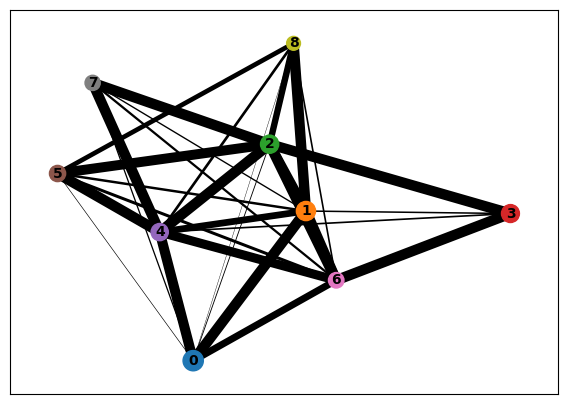

In [19]:
#calculate PAGA to reveal the topological structure of cell populations(differentiation trajectory, branches or cycles)
sc.tl.paga(adata_hvg, groups='leiden')
#help decide choosing the root cell from which cluster
sc.pl.paga(adata_hvg, color='leiden', threshold=0.02)

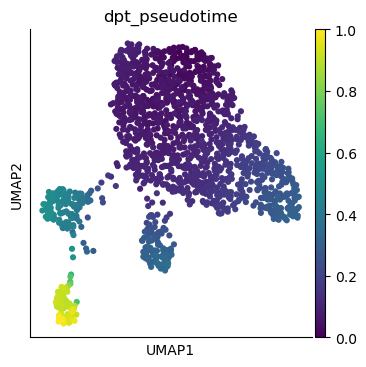

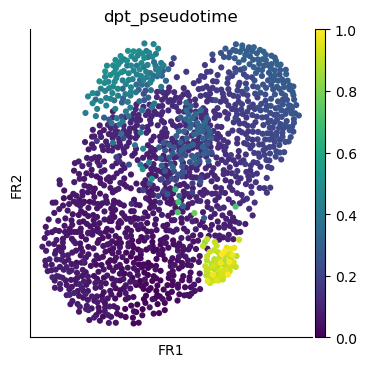

In [43]:
# 假设你分析的是 'adata_hvg'，并且 'Lgr5' 在 var_names 中
cluster1 = adata_hvg[adata_hvg.obs['leiden'] == '1']

# 获取 Lgr5 表达最高的细胞
import numpy as np
root_cell = cluster1.obs_names[np.argmax(cluster1[:, 'Lgr5'].X.toarray())]

import numpy as np
iroot = np.where(adata_hvg.obs_names == root_cell)[0][0]
# start from this root cell
adata_hvg.uns['iroot'] = iroot

#calculate diffusion map and DPT
sc.tl.diffmap(adata_hvg, n_comps=20)
sc.tl.dpt(adata_hvg)

#visualize the pseudotime distribution of cells
sc.pl.umap(adata_hvg, color='dpt_pseudotime', cmap='viridis')

#viewing trajectories
sc.tl.draw_graph(adata_hvg, layout='fr', init_pos='paga')
sc.pl.draw_graph(adata_hvg, color='dpt_pseudotime', cmap='viridis')

## Use CellRank to deduce Terminal Fates and driver genes

  0%|          | 0/1522 [00:00<?, ?cell/s]

  0%|          | 0/5 [00:00<?, ?/s]

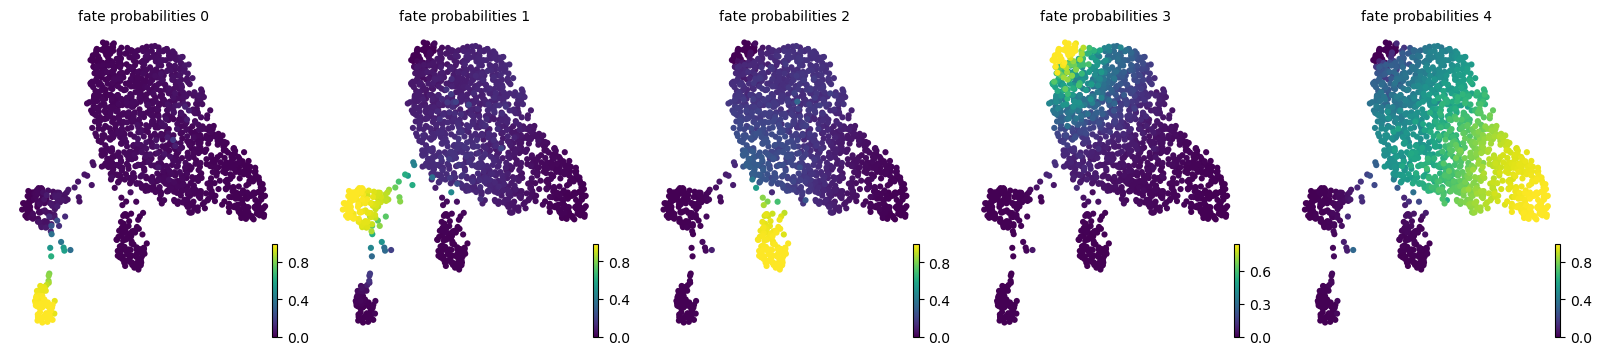

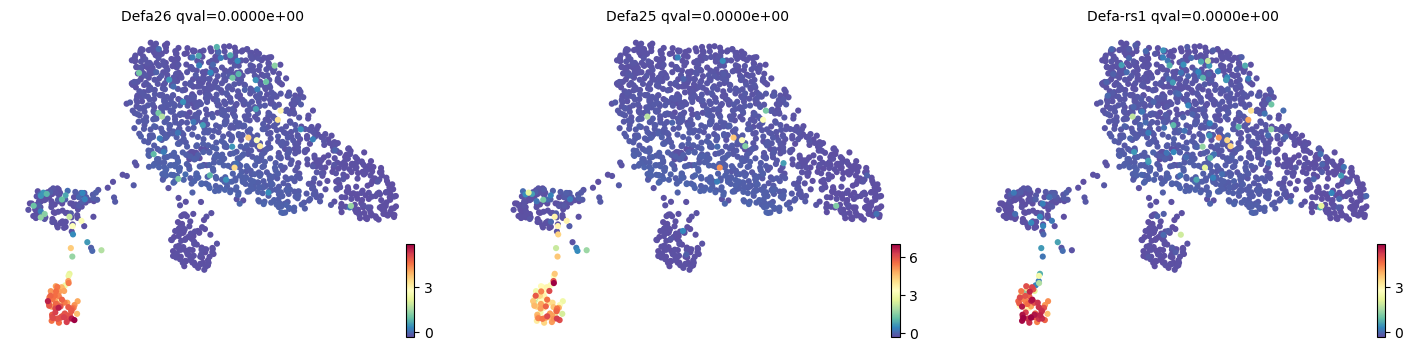

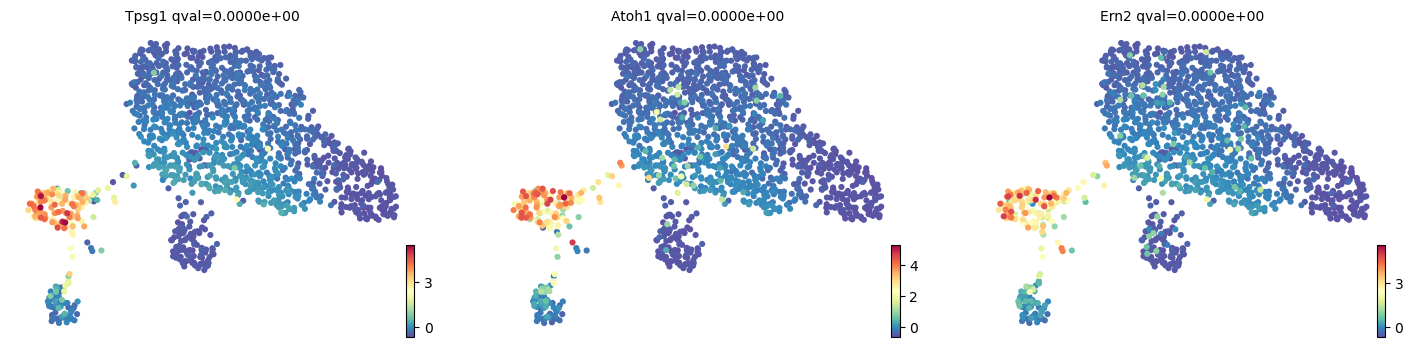

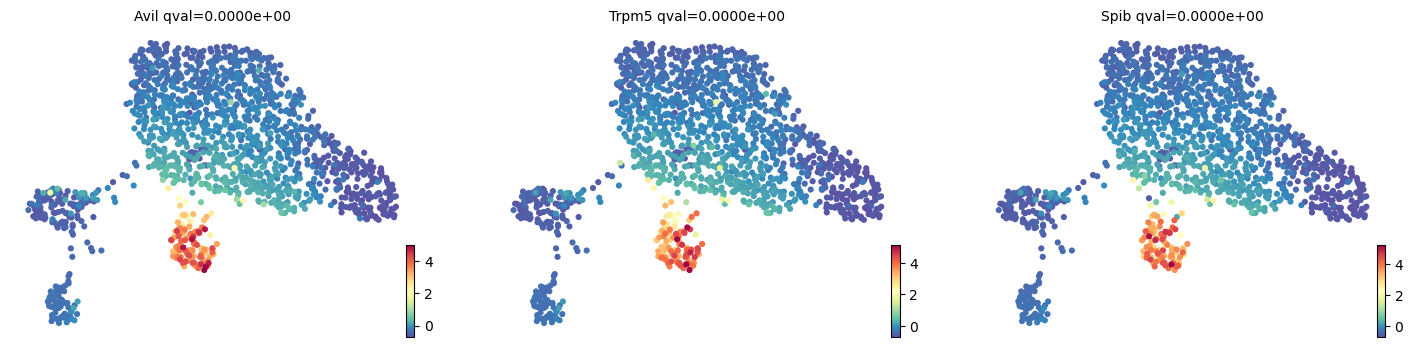

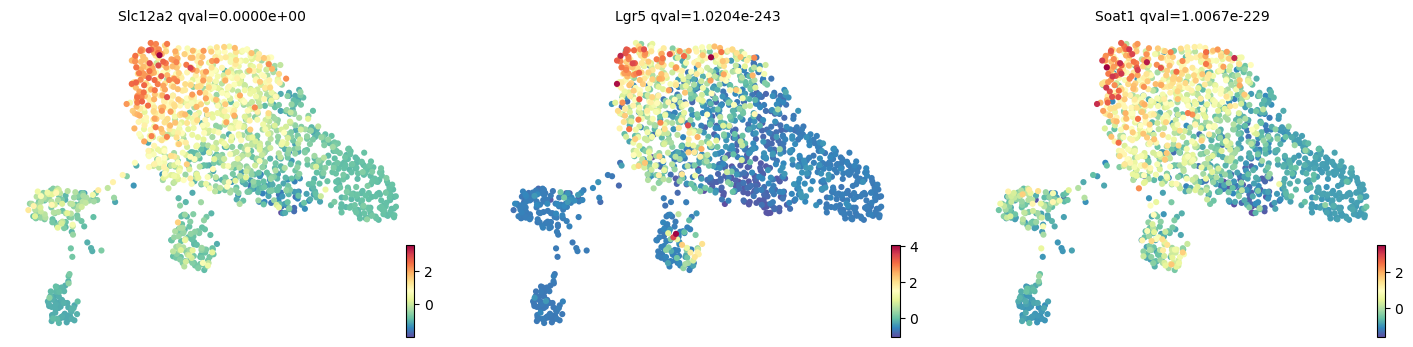

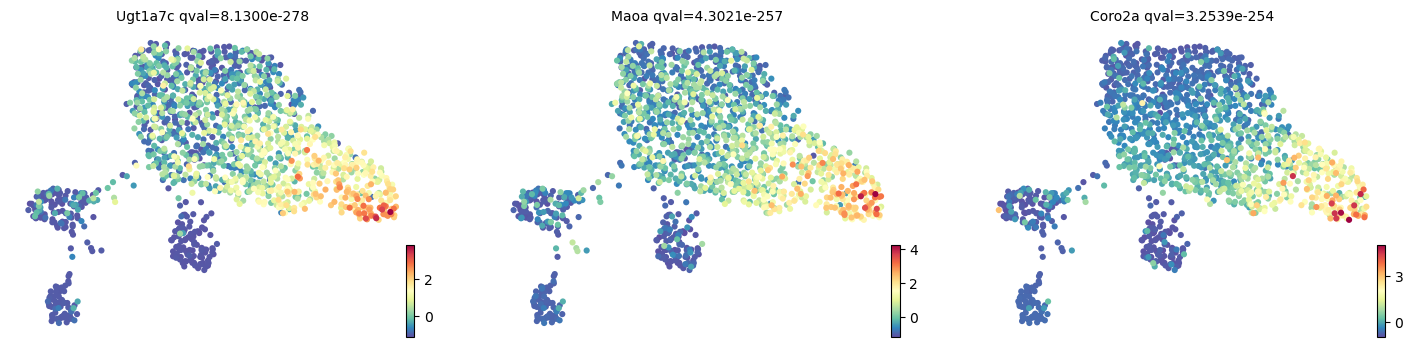

In [44]:
import cellrank as cr
import scanpy as sc

from cellrank.kernels import PseudotimeKernel
from cellrank.estimators import GPCCA

pk = PseudotimeKernel(adata_hvg, time_key='dpt_pseudotime')
pk.compute_transition_matrix()

g = GPCCA(pk)
g.fit(n_states=5) 

g.predict_terminal_states()
g.compute_fate_probabilities()
g.compute_lineage_drivers()

g.plot_fate_probabilities(same_plot=False)

cols = g._lineage_drivers.columns
lineage_ids = sorted(set(c.split('_')[0] for c in cols))

for lid in lineage_ids:
    g.plot_lineage_drivers(int(lid), n_genes=3)

## Trends for driver genes of each terminal states

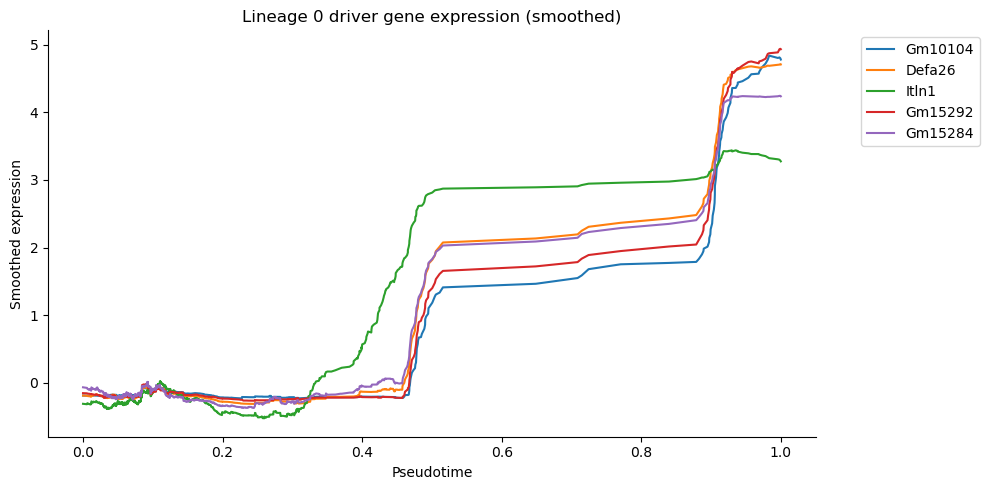

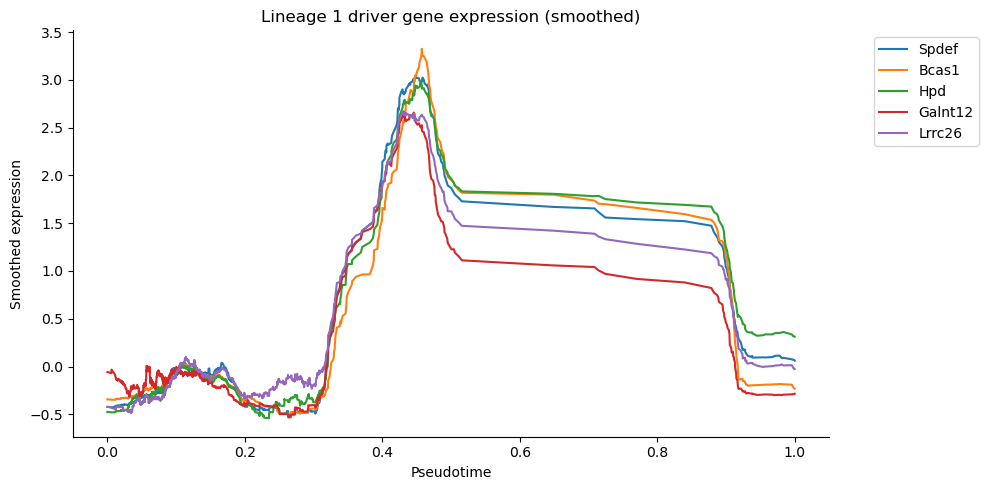

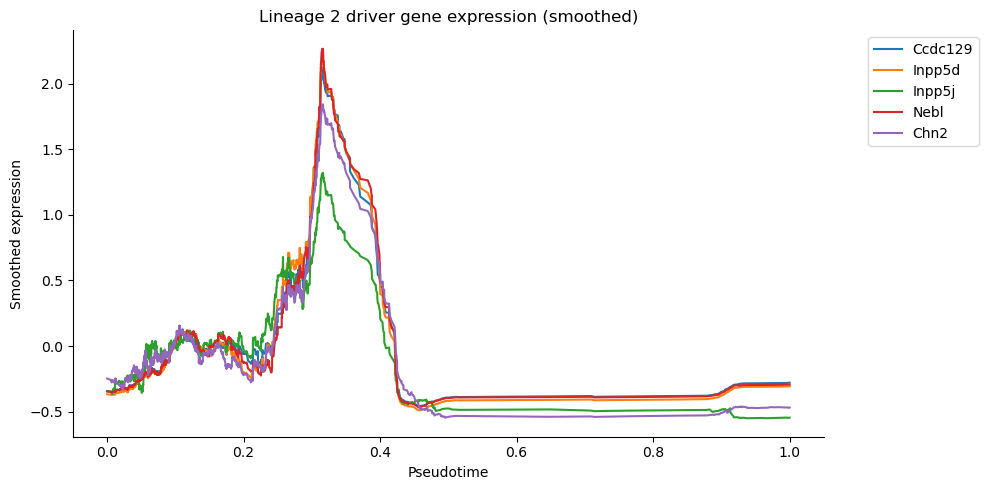

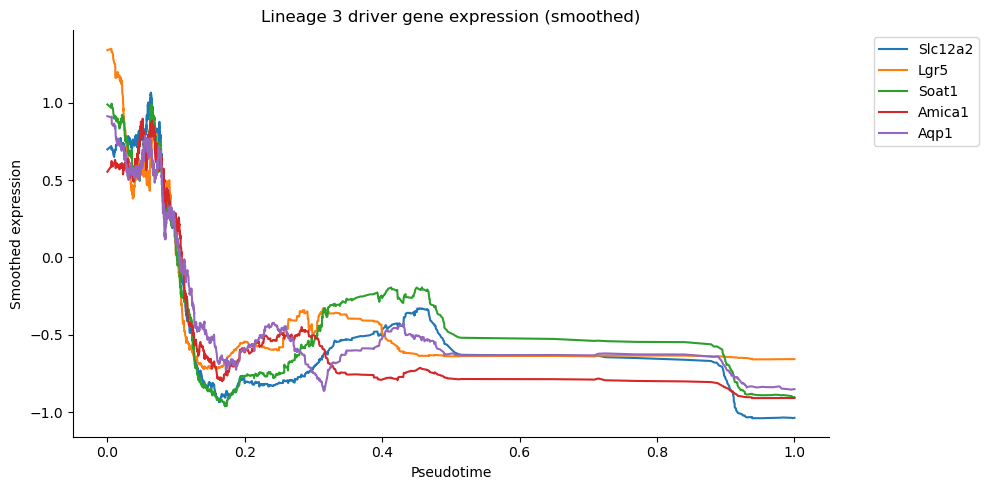

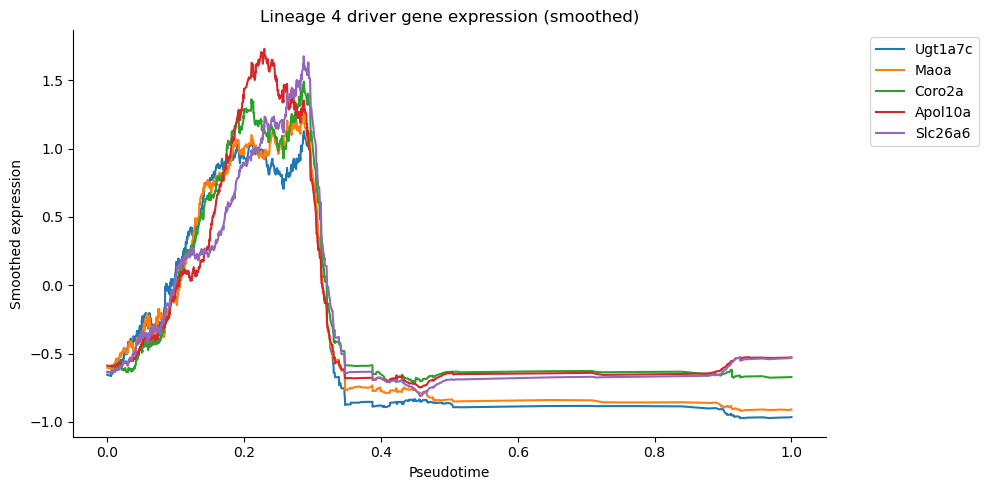

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

for lid in lineage_ids:
    lid = str(lid)
    # rank top 5 driver genes（ascending order in q-value）
    df_drivers = g._lineage_drivers.sort_values(by=f"{lid}_qval").head(5)
    top_genes = df_drivers.index.tolist()

    # build DataFrame：pseudotime + gene expression amount
    df = pd.DataFrame({"pseudotime": adata_hvg.obs["dpt_pseudotime"]})
    for gene in top_genes:
        df[gene] = adata_hvg[:, gene].X.toarray().flatten()

    df = df.sort_values("pseudotime")
    #rolling window to smooth the data and variation
    window_size = 80
    df_smooth = df.copy()
    for gene in top_genes:
        df_smooth[gene] = df[gene].rolling(window=window_size, center=True, min_periods=1).mean()

    #plotting
    plt.figure(figsize=(10, 5))
    for gene in top_genes:
        sns.lineplot(x=df_smooth["pseudotime"], y=df_smooth[gene], label=gene)

    plt.title(f"Lineage {lid} driver gene expression (smoothed)")
    plt.xlabel("Pseudotime")
    plt.ylabel("Smoothed expression")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Use Palantir to do Pseudo-time Analysis

In [46]:
import scvelo as scv 
import palantir
import scanpy as sc 
import pandas as pd
import os

# Plotting
import matplotlib
import matplotlib.pyplot as plt
# Inline plotting
%matplotlib inline

In [47]:
# 1. 运行 Diffusion Map，构建低维空间
dm_res = palantir.utils.run_diffusion_maps(adata_hvg, n_components=15)
ms_data = palantir.utils.determine_multiscale_space(adata_hvg)

In [48]:
#使用了 MAGIC 补全算法 来平滑单细胞数据，并进行基因表达趋势的可视化
imputed_X = palantir.utils.run_magic_imputation(adata_hvg)
adata_hvg.layers["MAGIC_imputed_data"] = imputed_X

In [49]:
import numpy as np
from scipy.stats import rankdata
# 你已经 MAGIC 补全过的表达矩阵
X = adata_hvg.layers["MAGIC_imputed_data"]

gene_to_index = {gene: i for i, gene in enumerate(adata_hvg.var_names)}
# 初始化一个列表用于存储每个细胞的类型
marker_based_types = []

# 遍历每个细胞
for i in range(adata_hvg.n_obs):
    cell_expr = X[i].toarray().flatten() # 第 i 个细胞的表达向量
    ranks = rankdata(cell_expr, method='average')
    scores = {}

    # 遍历参考字典中的每一个 cell type 和其 marker genes
    for celltype, genes in intestine_cell_markers.items():
        # 找到 marker genes 在 var_names 中的位置
        gene_indices = [gene_to_index[g] for g in genes if g in gene_to_index]

        # 有合法 marker genes，计算得分
        if gene_indices:
            scores[celltype] = np.mean(ranks[gene_indices])

    # 选出得分最高的 cell type
    if scores:
        best_type = max(scores, key=scores.get)
        marker_based_types.append(best_type)
    else:
        marker_based_types.append("Unclear")

# 存储在 adata_hvg.obs 中
adata_hvg.obs["marker_based_type"] = marker_based_types


In [50]:
#Aimed Terminal cell types
selected_fates = ['Goblet cell', 'Enterocyte', 'Enteroendocrine cell', 'Brush cell (Tuft cell)', 'Paneth cell']

terminal_cells = {}

for fate in selected_fates:  # 例如 ["Brush cell (Tuft cell)", "Enterocyte", ...]
    subset = adata_hvg[adata_hvg.obs['marker_based_type'] == fate]
    expr_matrix = subset.layers["MAGIC_imputed_data"]
    cell_scores = np.array(expr_matrix.sum(axis=1)).flatten()
    best_cell = subset.obs_names[cell_scores.argmax()]
    terminal_cells[best_cell] = fate
print(terminal_cells)

{'Goblet.43': 'Goblet cell', 'Enterocyte.122': 'Enterocyte', 'Stem.222': 'Enteroendocrine cell', 'TA.162': 'Brush cell (Tuft cell)', 'Paneth.46': 'Paneth cell'}


Sampling and flocking waypoints...
Time for determining waypoints: 0.0011530439058939615 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.20833457310994466 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


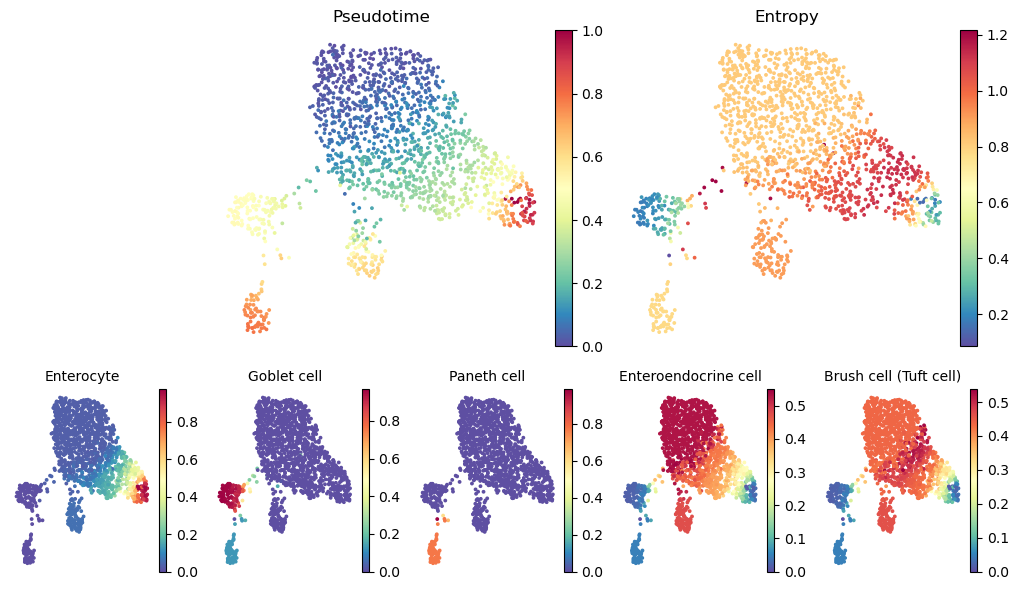

In [51]:
#convert to DataFrame
terminal_states = pd.Series(data=terminal_cells.values(), index=terminal_cells.keys())

pr_res = palantir.core.run_palantir(adata_hvg, root_cell, num_waypoints=500, terminal_states = terminal_states)

# Visualizing Palantir results
palantir.plot.plot_palantir_results(adata_hvg, s=3)
plt.show()

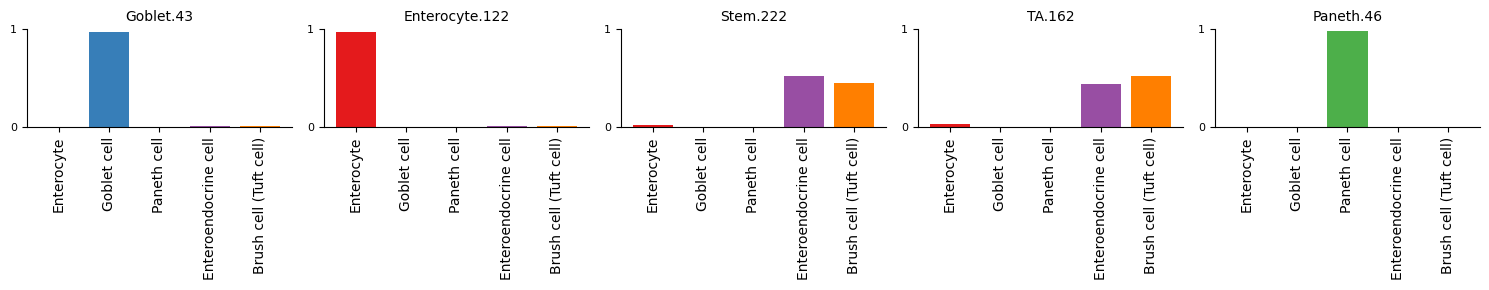

In [52]:
# 提取 terminal cell 的 cell ID 列表
cells = list(terminal_cells.keys())

# 创建子图图像对象, show terminal state probabilities
fig = palantir.plot.plot_terminal_state_probs(adata_hvg, cells)

for ax in fig.axes:
    for label in ax.get_xticklabels():
        label.set_rotation(90)

plt.tight_layout()
plt.show()

[]

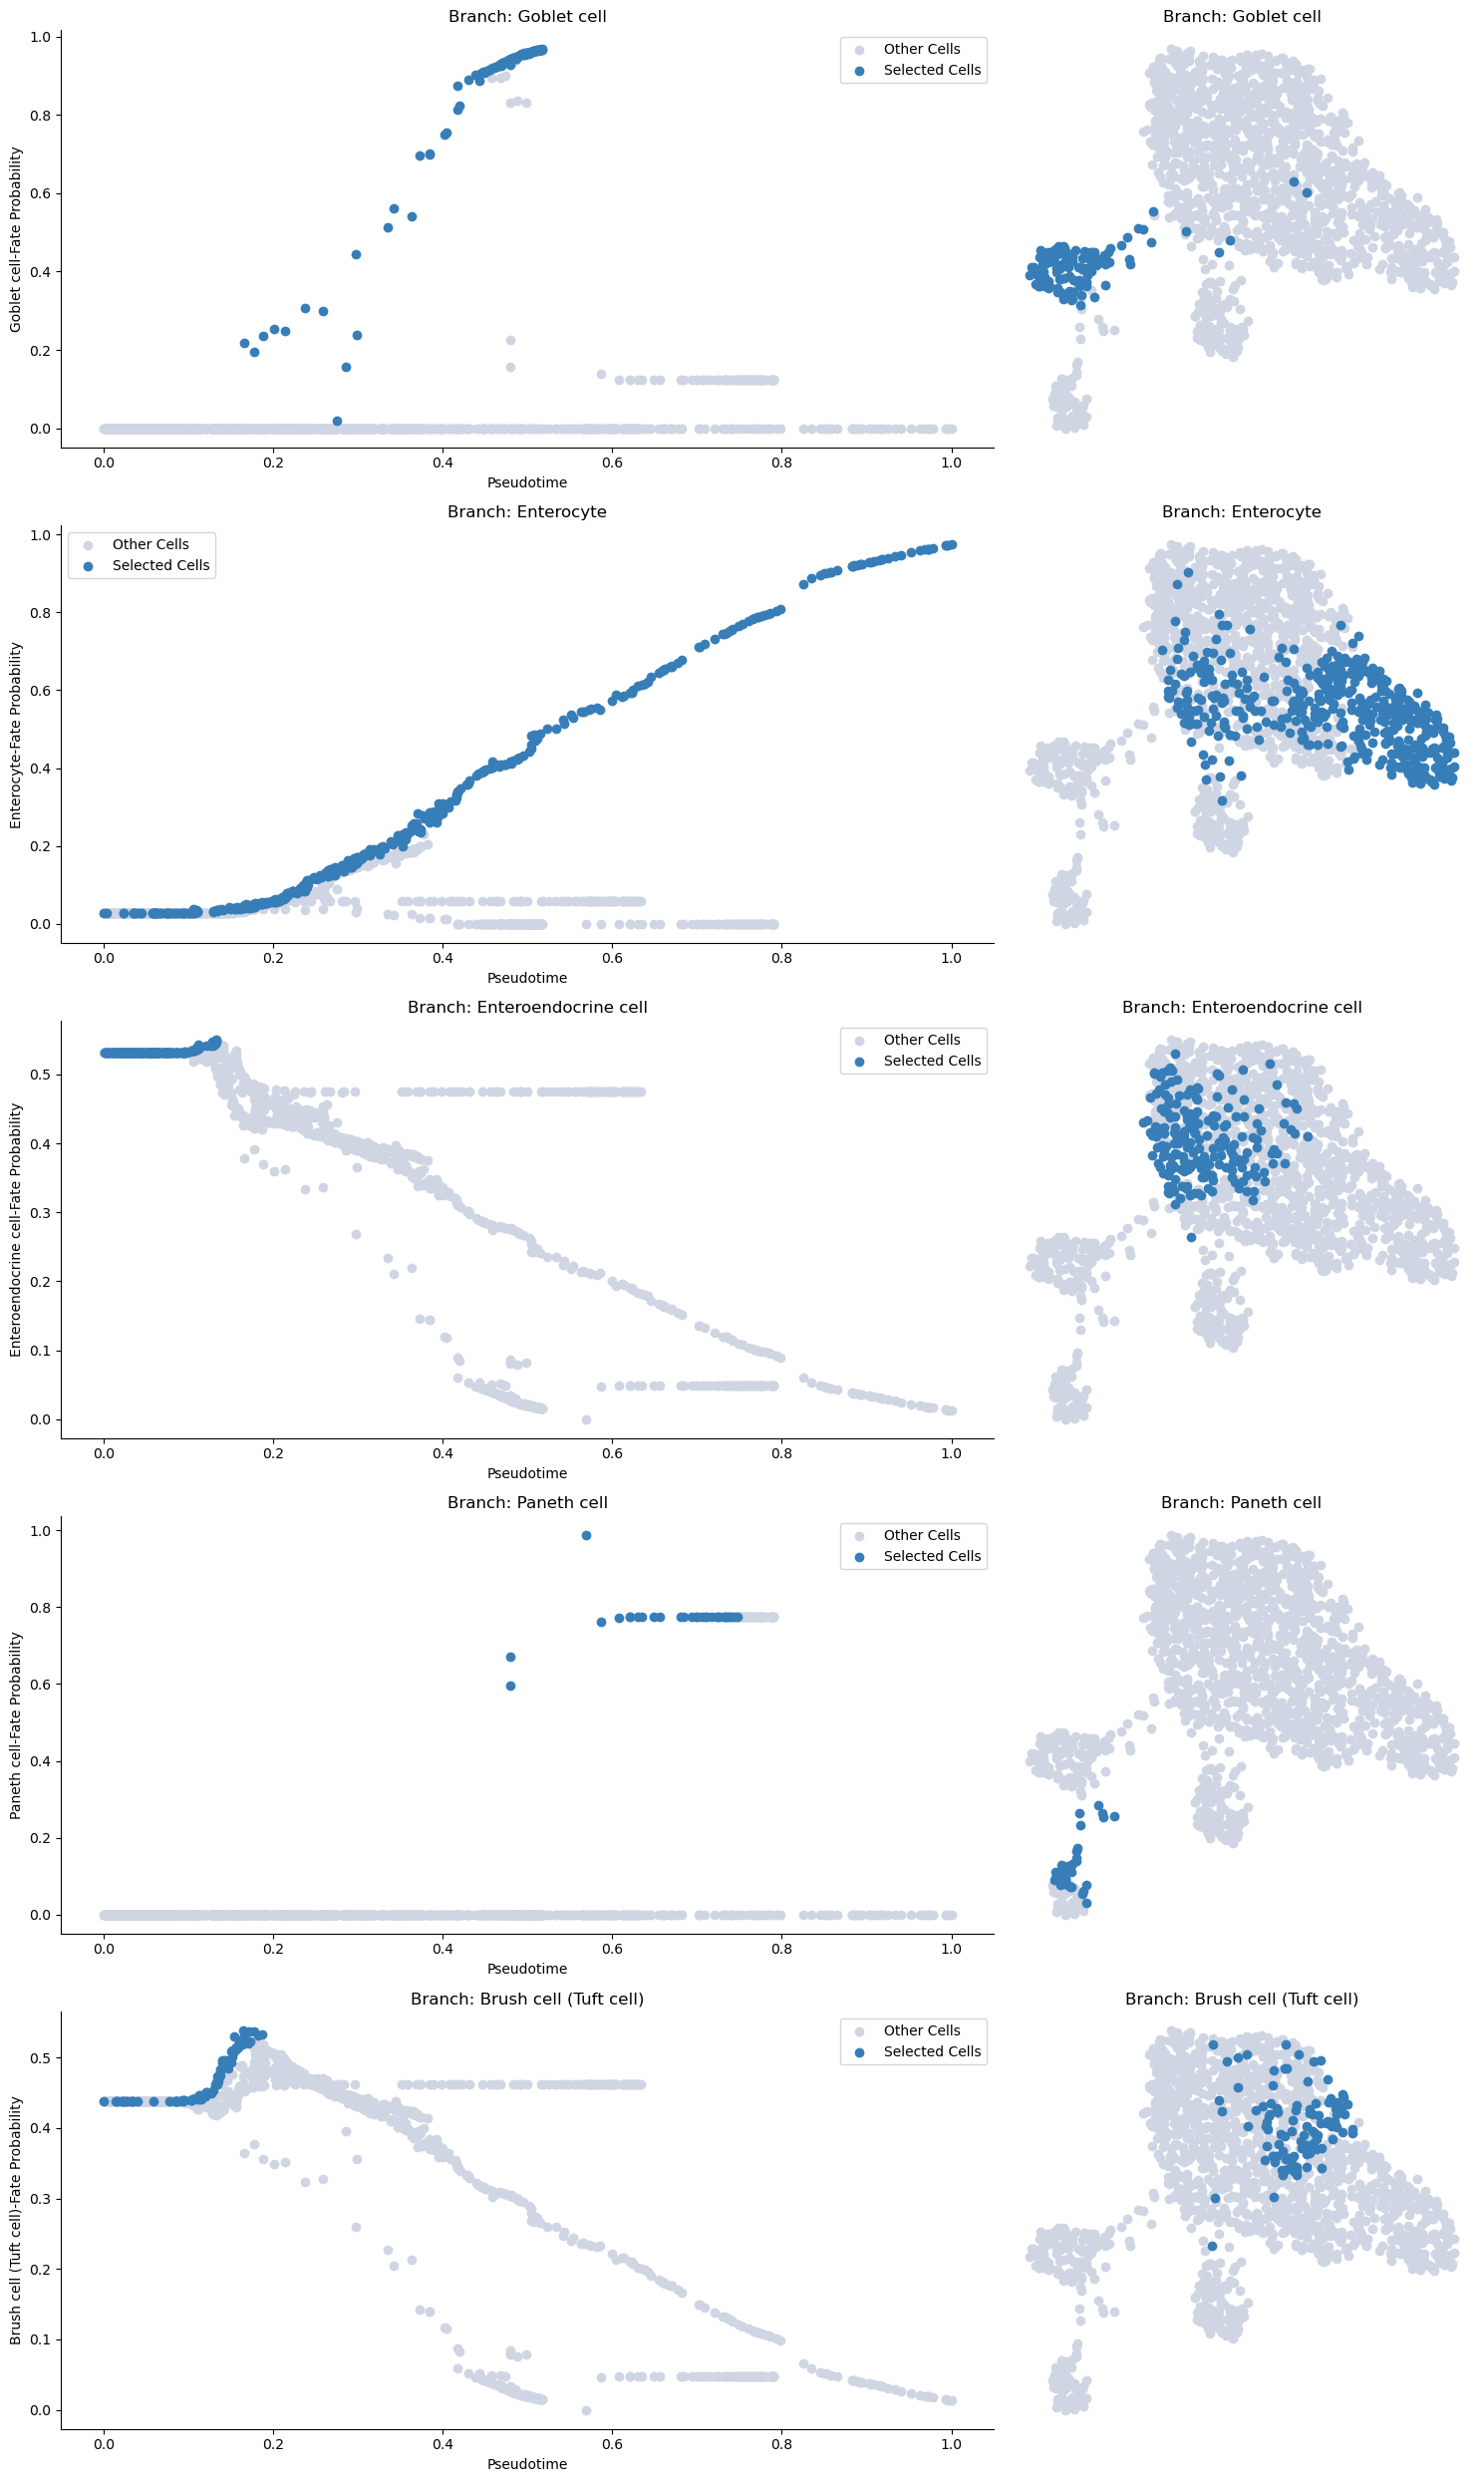

In [53]:
masks = palantir.presults.select_branch_cells(adata_hvg, eps=0)
palantir.plot.plot_branch_selection(adata_hvg)
plt.plot()

In [54]:
terminal_top_genes = {}

for cell in terminal_cells:
    # 从 MAGIC 补全后的表达矩阵中提取该 cell 的表达向量
    expr = adata_hvg.layers["MAGIC_imputed_data"][adata_hvg.obs_names == cell][0]
    
    # 找出表达量最大的 gene
    top_gene = adata_hvg.var_names[expr.argmax()]
    
    terminal_top_genes[cell] = top_gene

# 打印结果
for cell, gene in terminal_top_genes.items():
    print(f"{cell} ➤ 表达最强基因: {gene}")

Goblet.43 ➤ 表达最强基因: Scin
Enterocyte.122 ➤ 表达最强基因: Apoa1
Stem.222 ➤ 表达最强基因: Usp3
TA.162 ➤ 表达最强基因: Rangrf
Paneth.46 ➤ 表达最强基因: Reg4


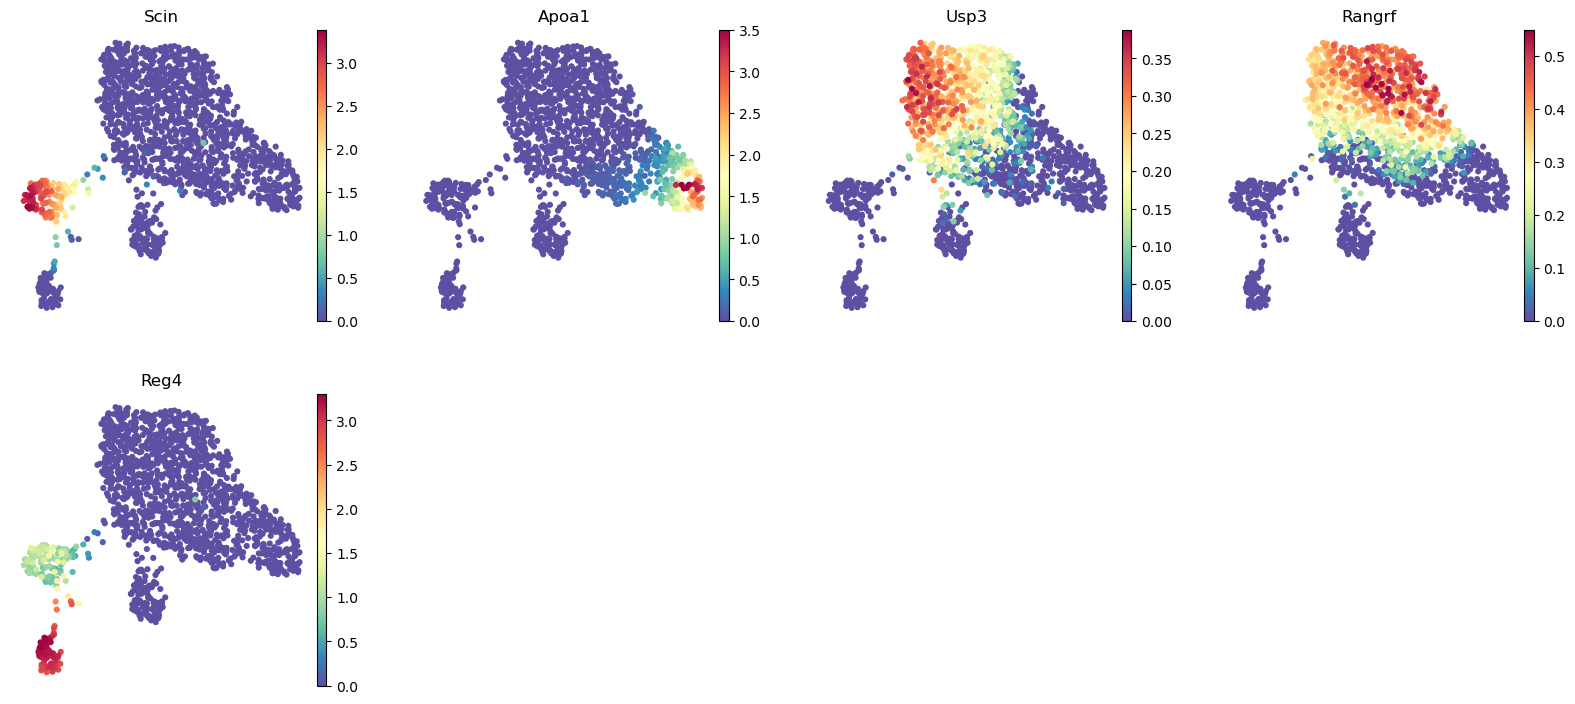

In [55]:
gene_list = list(terminal_top_genes.values())
sc.pl.embedding(
    adata_hvg,
    basis="umap",
    layer="MAGIC_imputed_data",
    color=gene_list,
    frameon=False
)

## Use LIANA to calculate cell-cell Interactions

In [66]:
import liana as li
from liana.mt import rank_aggregate

adata.obs['refined_type'] = adata_hvg.obs['refined_type']

li.mt.rank_aggregate(
    adata=adata,
    groupby='refined_type',
    resource_name='mouseconsensus',  # 注意这里叫 resource_name
    expr_prop=0.1,
    use_raw=False,
    verbose=True
)

# 3. 输出结果保存在以下位置：
df_liana = adata.uns['liana_res']

Generating ligand-receptor stats for 1522 samples and 1098 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:15<00:00, 64.34it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [72]:
adata_hvg.obs['dpt_bin'] = pd.qcut(adata_hvg.obs['dpt_pseudotime'], q=10, labels=[f"Bin{i}" for i in range(10)])
dpt_order = [f"Bin{i}" for i in range(10)]
adata_hvg.obs['dpt_bin'] = pd.Categorical(adata_hvg.obs['dpt_bin'], categories=dpt_order, ordered=True)

#parallel the pseudo-time data from adata_hvg to adata
adata.obs['dpt_pseudotime'] = adata_hvg.obs['dpt_pseudotime']
adata.obs['dpt_bin'] = adata_hvg.obs['dpt_bin']

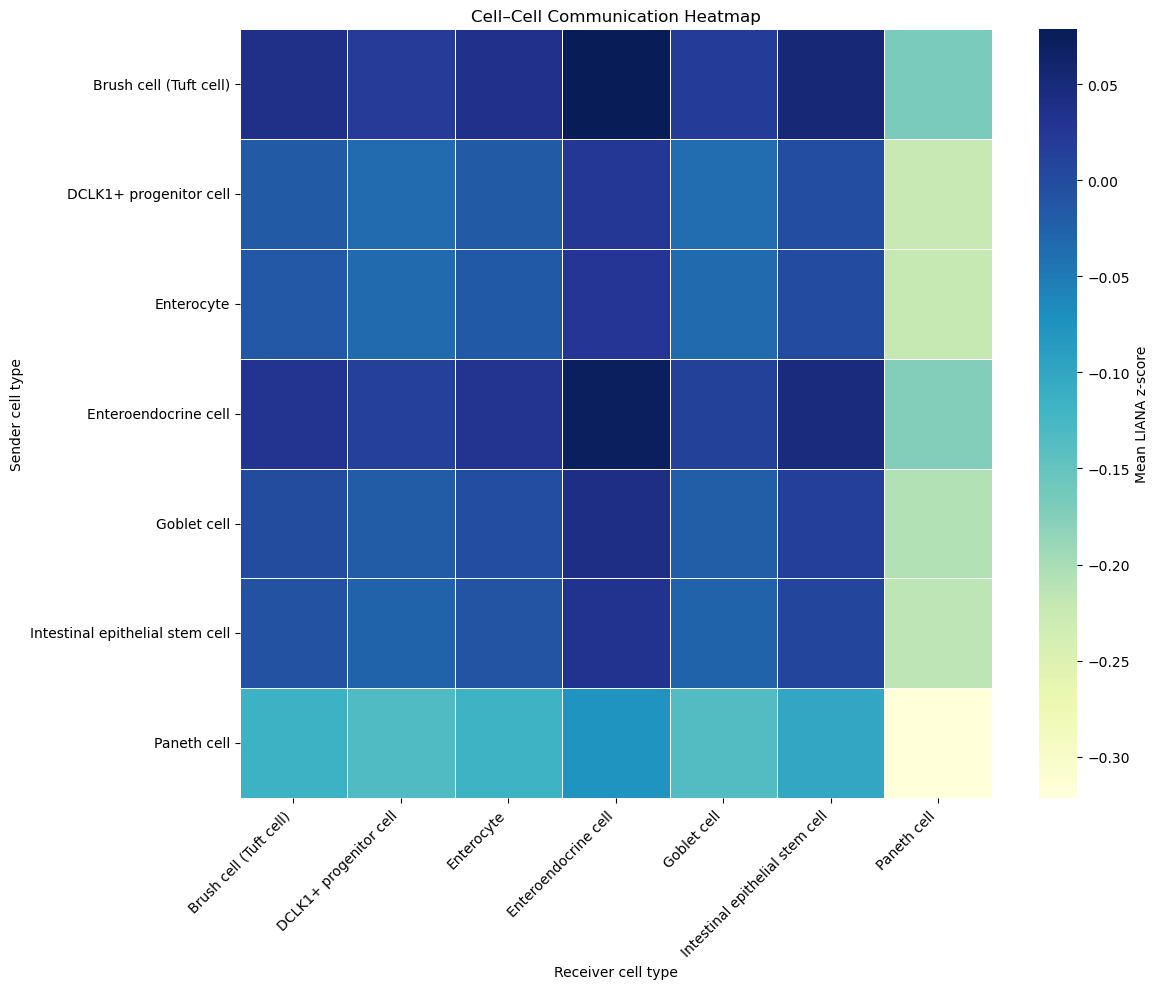

In [69]:
# ─────────────────────────────────────────────────────────
# 1) Imports
# ─────────────────────────────────────────────────────────
import scanpy as sc
import liana as li
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────
# 2) Make sure you have a cell-type column in adata.obs
#    Change TYPE_KEY if yours is named differently.
# ─────────────────────────────────────────────────────────
TYPE_KEY = "refined_type"
adata = adata[adata.obs[TYPE_KEY].notna()].copy()

# ─────────────────────────────────────────────────────────
# 3) Run LIANA’s rank_aggregate on the whole dataset
# ─────────────────────────────────────────────────────────
li.mt.rank_aggregate(
    adata         = adata,
    groupby       = TYPE_KEY,
    resource_name = "mouseconsensus",  # or "omnipath", etc.
    expr_prop     = 0.1,
    use_raw       = False,
    min_cells     = 2,
    verbose       = False
)

# ─────────────────────────────────────────────────────────
# 4) Pull results & detect best score column
# ─────────────────────────────────────────────────────────
df = adata.uns["liana_res"].copy()

# find which score columns are available
available = set(df.columns) & {"weight", "scaled_weight", "magnitude_rank"}
if not available:
    raise KeyError("No 'weight', 'scaled_weight' or 'magnitude_rank' in liana_res!")

# priority: weight > scaled_weight > magnitude_rank
if "weight" in available:
    df = df[df["weight"].notna()]
    df["score"]       = df["weight"]                 # raw 0→1
    cbar_label        = "Mean LIANA weight (0–1)"
elif "scaled_weight" in available:
    df = df[df["scaled_weight"].notna()]
    df["score"]       = df["scaled_weight"]          # z-score
    cbar_label        = "Mean LIANA z-score"
else:
    df = df[df["magnitude_rank"].notna()]
    df["score"]       = 1 - df["magnitude_rank"]     # invert so high=strong
    cbar_label        = "Mean LIANA consensus score"

# ─────────────────────────────────────────────────────────
# 5) Pivot & Plot
# ─────────────────────────────────────────────────────────
heat_df = (
    df.pivot_table(
        index   = "source",    # sender cell type
        columns = "target",    # receiver cell type
        values  = "score",
        aggfunc = "mean"
    )
    .fillna(0)
)

if heat_df.empty:
    raise ValueError(
        "After selecting your score column, the interaction matrix is empty.\n"
        "Check your filters (expr_prop, min_cells) or your cell-type labels."
    )

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    heat_df.sort_index().loc[:, heat_df.columns.sort_values()],
    cmap       = "YlGnBu",
    linewidths = 0.4,
    linecolor  = "white",
    cbar_kws   = {"label": cbar_label}
)

ax.set_title("Cell–Cell Communication Heatmap")
ax.set_xlabel("Receiver cell type")
ax.set_ylabel("Sender cell type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

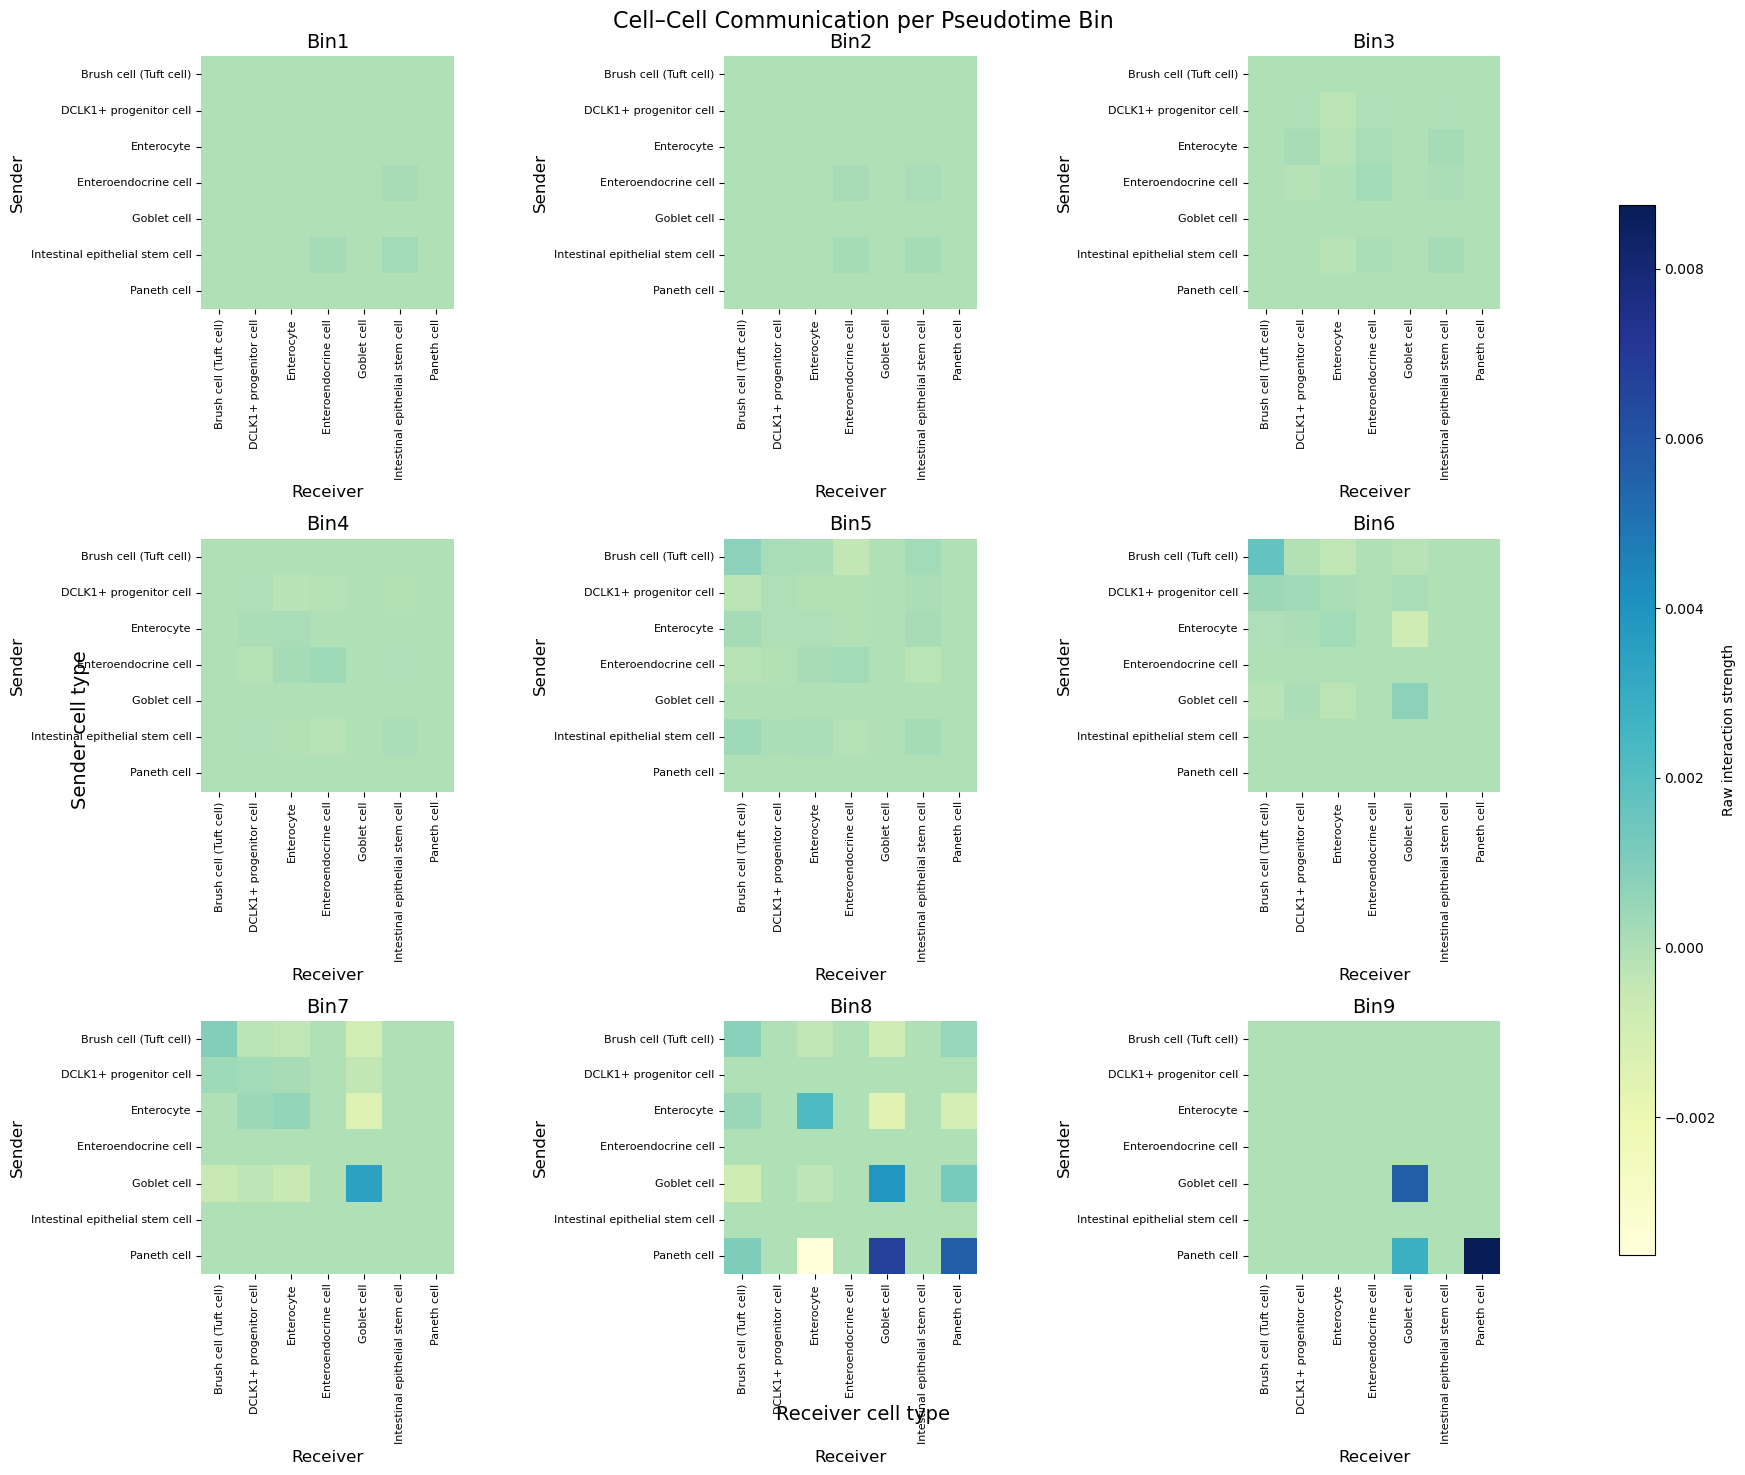

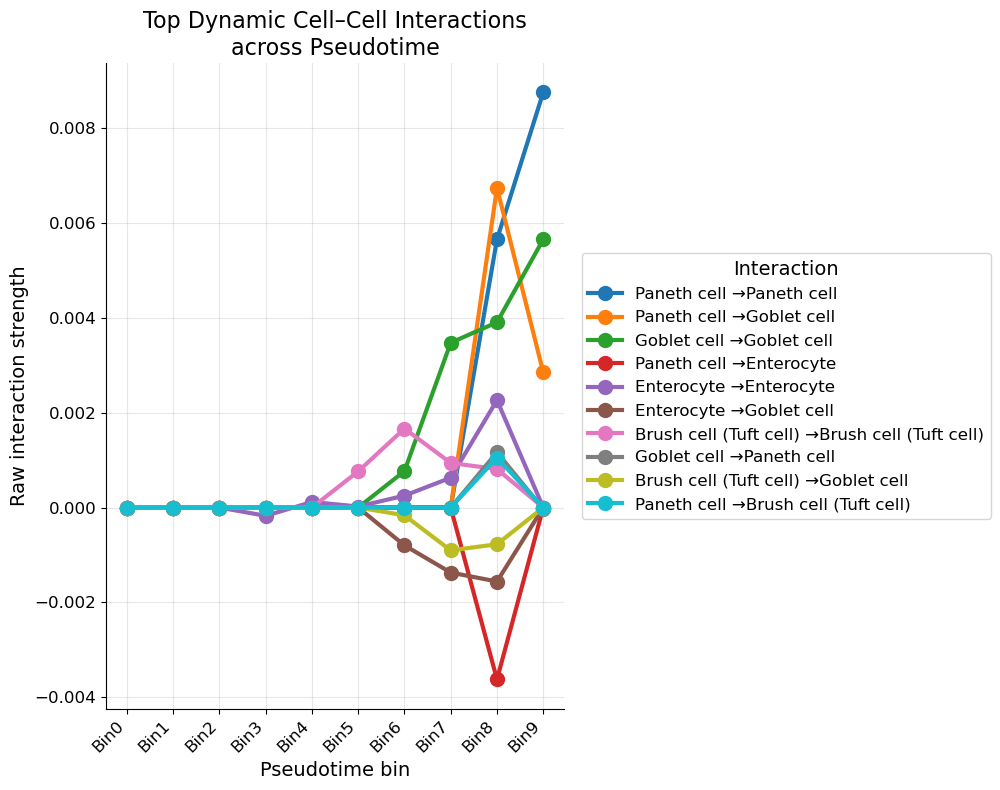

In [79]:
# ─────────────────────────── Imports ────────────────────────────────
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────── USER CONFIG ───────────────────────────
TYPE_KEY   = "refined_type"      # cell‑type column in adata.obs
PST_KEY    = "dpt_pseudotime"    # numeric pseudotime in adata.obs
N_BINS     = 10                  # number of pseudotime bins
MIN_CELLS  = 3                   # skip any cell‑type < this per bin
RESOURCE   = "mouseconsensus"    # LIANA resource
EXPR_PROP  = 0.1
TOP_N      = 10                   # # top dynamic interactions for line plot

# ──────────────────── 1) Create ordered pseudotime bins ────────────
# Make sure pseudotime is numeric
adata.obs[PST_KEY] = adata.obs[PST_KEY].astype(float)

# Define bin labels in numeric order *once* and reuse everywhere
bin_order = [f"Bin{i}" for i in range(N_BINS)]

adata.obs["pst_bin"] = pd.qcut(
    adata.obs[PST_KEY],
    q=N_BINS,
    labels=bin_order,
)
# **Key fix** – make it an *ordered* Categorical so Pandas preserves order
adata.obs["pst_bin"] = pd.Categorical(
    adata.obs["pst_bin"],
    categories=bin_order,
    ordered=True,
)

# ───────────────── 2) Run LIANA in each bin (loop over bins) ────────
all_res = []
for b in bin_order:  # iterate in the correct order directly
    mask = (adata.obs["pst_bin"] == b) & adata.obs[TYPE_KEY].notna()
    sub  = adata[mask].copy()
    if sub.n_obs < MIN_CELLS:
        continue

    # Drop rare cell types within this bin
    vc   = sub.obs[TYPE_KEY].value_counts()
    keep = vc[vc >= MIN_CELLS].index
    sub  = sub[sub.obs[TYPE_KEY].isin(keep)].copy()
    if sub.obs[TYPE_KEY].nunique() < 2:
        continue

    li.mt.rank_aggregate(
        adata         = sub,
        groupby       = TYPE_KEY,
        resource_name = RESOURCE,
        expr_prop     = EXPR_PROP,
        use_raw       = False,
        min_cells     = MIN_CELLS,
        verbose       = False,
    )

    df = sub.uns["liana_res"].copy()

    # ─────── choose a *raw* score (no z‑scaling) ────────
    raw_priority = ["expr_prod", "lr_means", "lrscore", "lr_logfc"]
    for col in raw_priority:
        if col in df.columns and df[col].notna().any():
            df["score"] = df[col]
            break
    else:  # fall‑back if no raw metric is present
        df["score"] = 1 - df["magnitude_rank"]

    # Optional dynamic‑range compression (uncomment if desired)
    # df["score"] = np.log1p(df["score"])

    df["pst_bin"]     = b
    df["interaction"] = df["source"] + "▶️" + df["target"]
    all_res.append(df[["pst_bin", "interaction", "score"]])

# Concatenate all bins into a single long DataFrame
if not all_res:
    raise ValueError("No LIANA results collected – check data & thresholds.")

df_all = pd.concat(all_res, ignore_index=True)

# ──────────────── 3) Build bin × interaction matrix ────────────────
mat = (
    df_all
    .pivot_table(
        index   = "pst_bin",
        columns = "interaction",
        values  = "score",
        aggfunc = "mean",
        sort    = False,          # **preserve the categorical order**
    )
    .reindex(bin_order, axis=0)   # **double‑check row order**
    .fillna(0)
)

# Only keep bins that actually have data (optional)
bins_present = [b for b in bin_order if (mat.loc[b].sum() > 0)]

# ───────────────────────── 4A) Per‑bin heat‑maps ────────────────────
if bins_present:
    n_bins  = len(bins_present)
    n_cols  = 3
    n_rows  = int(np.ceil(n_bins / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*5), squeeze=False)

    vmin, vmax = mat.values.min(), mat.values.max()
    cmap = "YlGnBu"

    for idx, bin_name in enumerate(bins_present):
        r, c = divmod(idx, n_cols)
        ax   = axes[r][c]

        s   = mat.loc[bin_name]
        dfb = pd.DataFrame({"interaction": s.index, "score": s.values})
        dfb[["source", "target"]] = dfb["interaction"].str.split("▶️", expand=True)

        heat = (
            dfb.pivot_table(
                index="source",
                columns="target",
                values="score",
                aggfunc="mean",
            )
            .fillna(0)
        )

        sns.heatmap(
            heat, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
            cbar=False, square=True,
        )
        ax.set_title(bin_name, fontsize=14)
        ax.set_xlabel("Receiver", fontsize=12)
        ax.set_ylabel("Sender", fontsize=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

    # remove empty subplots
    for idx in range(n_bins, n_rows * n_cols):
        fig.delaxes(axes.flatten()[idx])

    # shared colour‑bar
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, label="Raw interaction strength")

    fig.suptitle("Cell–Cell Communication per Pseudotime Bin", fontsize=16, y=0.98)
    fig.text(0.5, 0.04, "Receiver cell type", ha="center", fontsize=14)
    fig.text(0.06, 0.5, "Sender cell type", va="center", rotation="vertical", fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()
else:
    print("No bins passed QC – skipping heat‑map section.")

# ───────────────────────── 4B) “Top Dynamic” line plot ──────────────
if not mat.empty:
    var     = mat.var(axis=0)
    top_dyn = var.nlargest(TOP_N).index.tolist()

    plt.figure(figsize=(12, 8))
    for interaction in top_dyn:
        plt.plot(
            mat.index,
            mat[interaction],
            marker='o',
            markersize=10,
            linewidth=3,
            label=interaction.replace("▶️", " →"),
        )

    plt.xticks(mat.index, mat.index, rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("Pseudotime bin", fontsize=14)
    plt.ylabel("Raw interaction strength", fontsize=14)
    plt.title("Top Dynamic Cell–Cell Interactions\nacross Pseudotime", fontsize=16)
    plt.legend(
        title="Interaction", title_fontsize=14,
        fontsize=12, loc='center left', bbox_to_anchor=(1.02, 0.5),
    )
    plt.grid(alpha=0.3)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()
else:
    print("Matrix is empty – skipping dynamic‑line plot.")


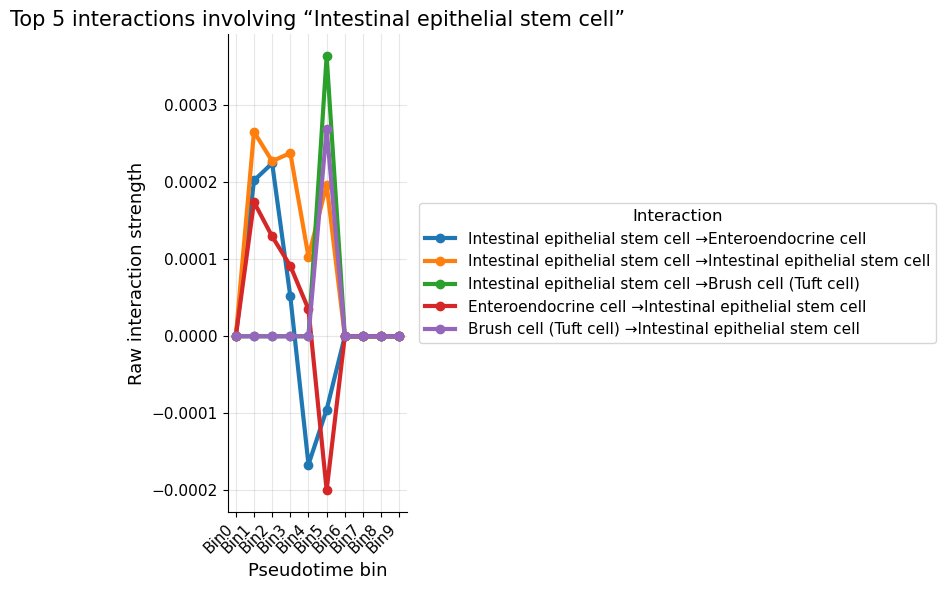

In [80]:
# ─────────────── 4C) 只看 “Intestinal epithelial stem cell” 相关 ───────────────
TARGET = "Intestinal epithelial stem cell"   # 你要关注的细胞类型
N_STEM = 5                                   # 取前 N 条（按方差）

# 1) 用列名里是否包含目标字符串来挑选互作
stem_cols = [c for c in mat.columns if TARGET in c]

if not stem_cols:
    print(f"No interactions involving ‘{TARGET}’ were found.")
else:
    # 2) 计算这些互作在各 bin 的方差，选前 N_STEM 条
    stem_var   = mat[stem_cols].var(axis=0, skipna=True)
    top_stem   = stem_var.nlargest(N_STEM).index.tolist()

    # 3) 画图
    plt.figure(figsize=(10, 6))
    for inter in top_stem:
        plt.plot(
            mat.index, mat[inter],
            marker='o', linewidth=3,
            label=inter.replace("▶", " →")        # 如果分隔符是 ▶️ 改成对应字符
        )

    plt.xticks(mat.index, mat.index, rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.xlabel("Pseudotime bin", fontsize=13)
    plt.ylabel("Raw interaction strength", fontsize=13)
    plt.title(f"Top {len(top_stem)} interactions involving “{TARGET}”", fontsize=15)
    plt.legend(title="Interaction", title_fontsize=12,
               fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.grid(alpha=0.3)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


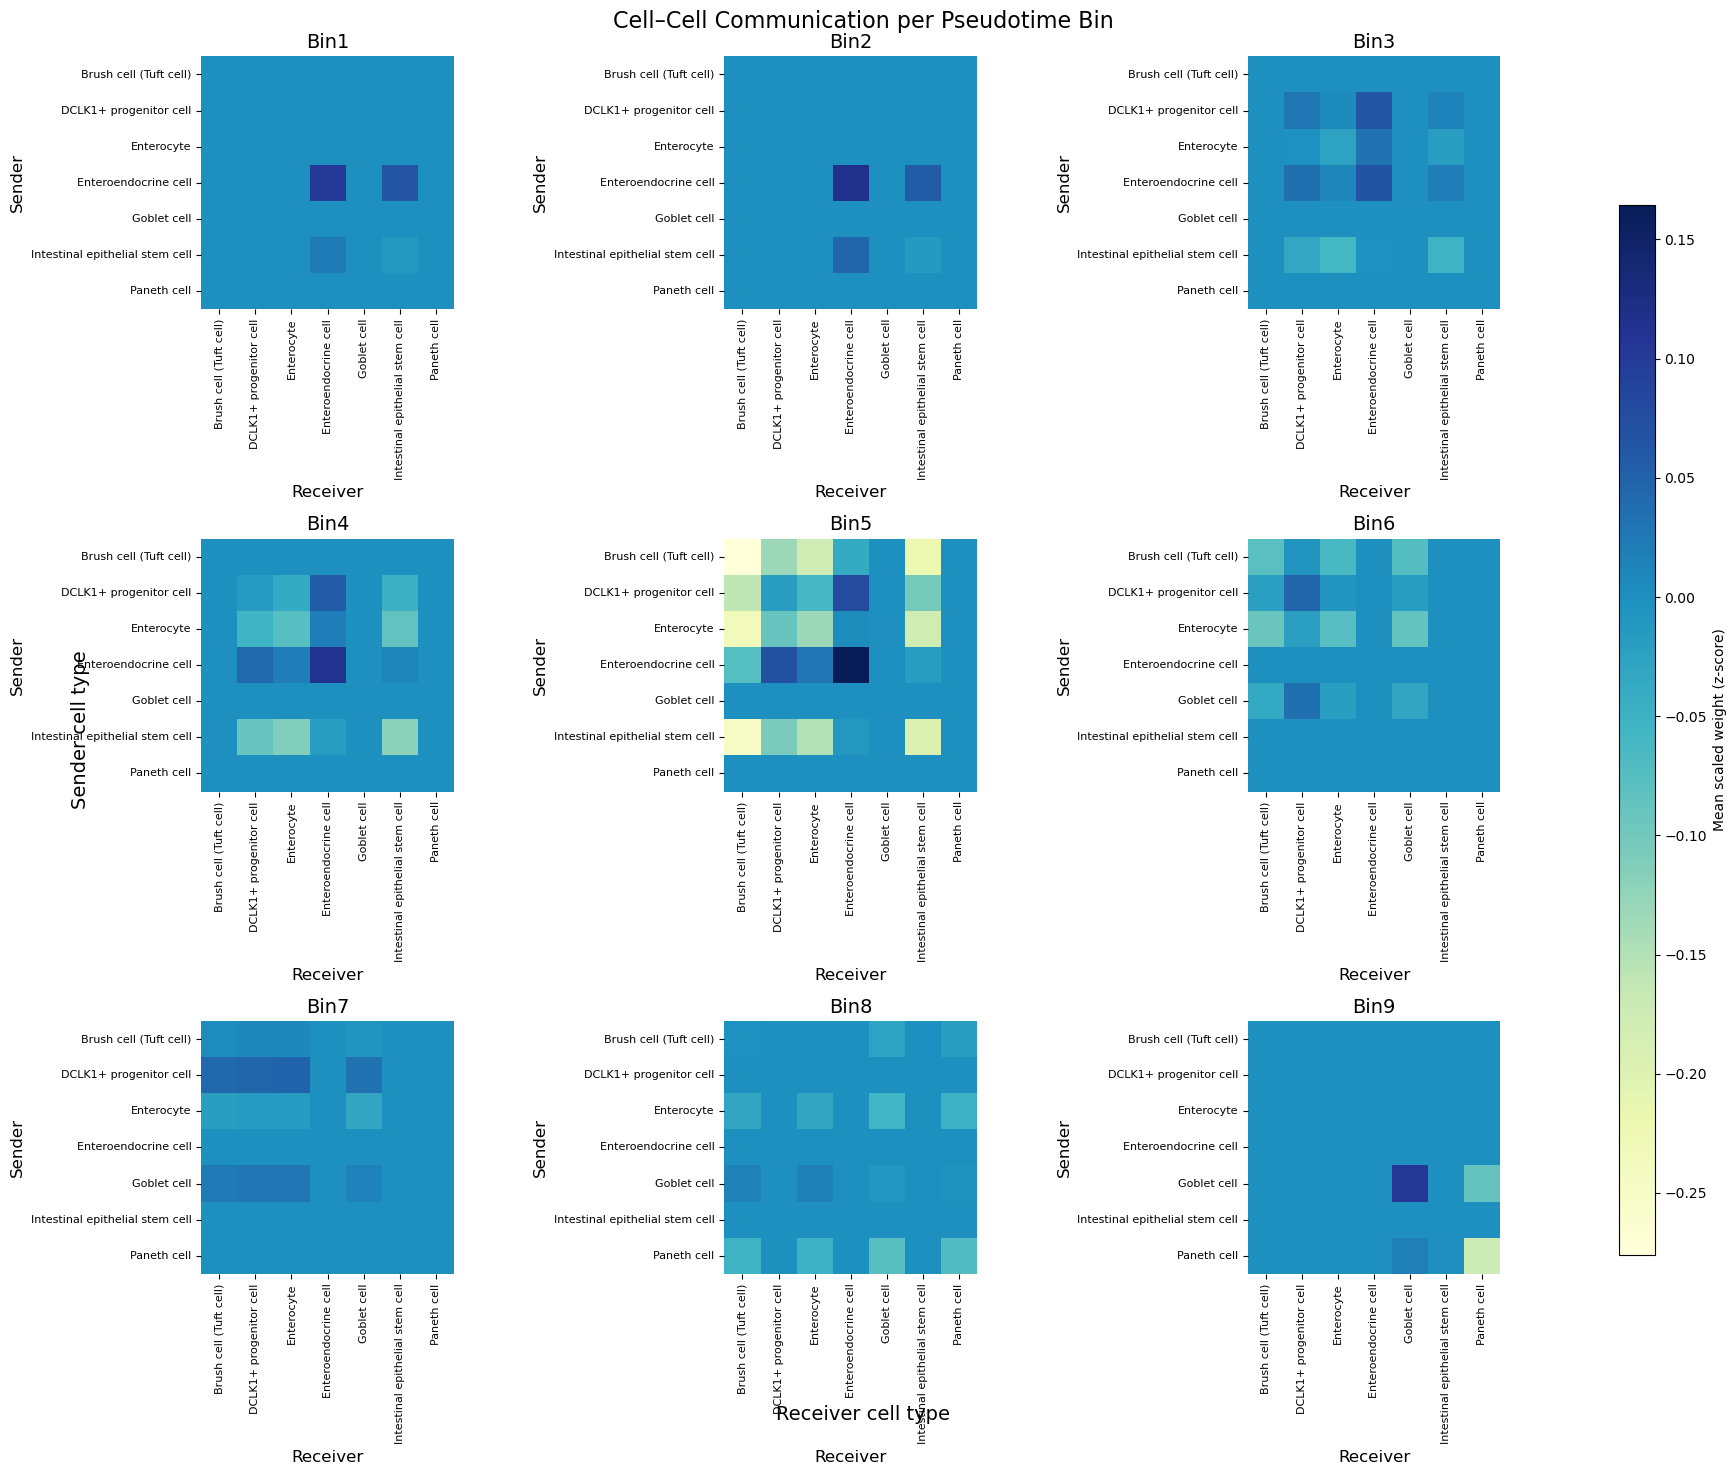

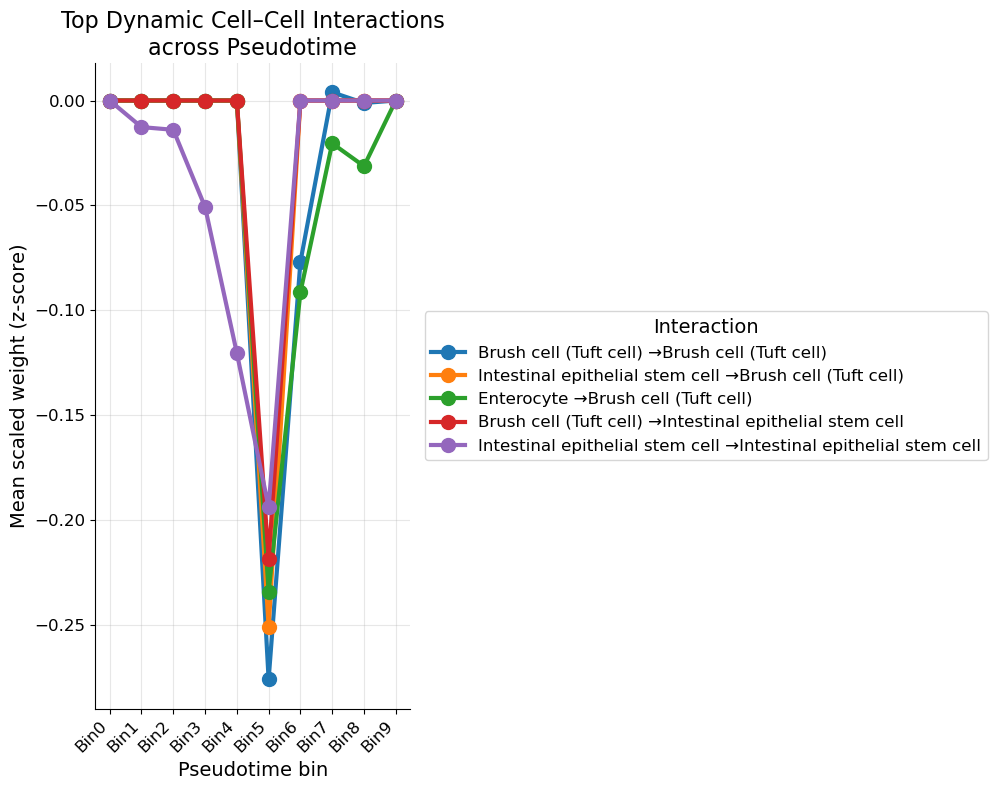

In [76]:
# ─────────────────────────── Imports ────────────────────────────────
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────── USER CONFIG ───────────────────────────
TYPE_KEY   = "refined_type"       # cell type column in adata.obs
PST_KEY    = "dpt_pseudotime"     # numeric pseudotime in adata.obs
N_BINS     = 10                    # how many pseudotime bins
MIN_CELLS  = 3                     # skip any cell-type < this per bin
RESOURCE   = "mouseconsensus"      # LIANA resource
EXPR_PROP  = 0.10
TOP_N      = 5                     # top dynamic interactions for line plot
FIG_SIZE   = (3, 3)                # size for each bin–heatmap (unused below)

# ──────────────────── 1) Create *ordered* pseudotime bins ──────────
adata.obs[PST_KEY] = adata.obs[PST_KEY].astype(float)

# Pre‑define the correct numeric order once and reuse it everywhere
bin_order = [f"Bin{i}" for i in range(N_BINS)]

adata.obs["pst_bin"] = pd.Categorical(
    pd.qcut(adata.obs[PST_KEY], q=N_BINS, labels=bin_order),
    categories=bin_order,
    ordered=True,
)

# ───────────────── 2) Run LIANA in each bin ─────────────────────────
all_res = []
for b in bin_order:                         # iterate in correct order
    mask = (adata.obs["pst_bin"] == b) & adata.obs[TYPE_KEY].notna()
    sub  = adata[mask].copy()
    if sub.n_obs < MIN_CELLS:
        continue

    # drop rare sender/receiver types within this bin
    vc   = sub.obs[TYPE_KEY].value_counts()
    keep = vc[vc >= MIN_CELLS].index
    sub  = sub[sub.obs[TYPE_KEY].isin(keep)].copy()
    if sub.obs[TYPE_KEY].nunique() < 2:
        continue

    li.mt.rank_aggregate(
        adata         = sub,
        groupby       = TYPE_KEY,
        resource_name = RESOURCE,
        expr_prop     = EXPR_PROP,
        use_raw       = False,
        min_cells     = MIN_CELLS,
        verbose       = False,
    )

    df = sub.uns["liana_res"].copy()

    # prefer scaled_weight, else invert magnitude_rank
    if "scaled_weight" in df.columns and df["scaled_weight"].notna().any():
        df = df[df["scaled_weight"].notna()].copy()
        df["score"] = df["scaled_weight"]
    else:
        df = df[df["magnitude_rank"].notna()].copy()
        df["score"] = 1 - df["magnitude_rank"]

    df["pst_bin"]     = b
    df["interaction"] = df["source"] + "▶" + df["target"]
    all_res.append(df[["pst_bin", "interaction", "score"]])

# concatenate all bins
if not all_res:
    raise ValueError("No LIANA results collected – check data thresholds.")

df_all = pd.concat(all_res, ignore_index=True)

# ──────────────── 3) Build bin × interaction matrix ─────────────────
mat = (
    df_all
      .pivot_table(
         index   = "pst_bin",
         columns = "interaction",
         values  = "score",
         aggfunc = "mean",
         sort    = False,                # respect categorical order
      )
      .reindex(bin_order, axis=0)        # double‑check row order
      .fillna(0)
)

# ───────────────────────── 4A) Per‑bin heat‑maps ────────────────────
bins_present = [b for b in bin_order if (b in mat.index and mat.loc[b].sum() != 0)]

n_bins  = len(bins_present)
if n_bins == 0:
    raise ValueError("No bins with data – aborting plots.")

n_cols  = 3
n_rows  = int(np.ceil(n_bins / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*5), squeeze=False)

vmin, vmax = mat.values.min(), mat.values.max()
cmap = "YlGnBu"

for idx, bin_name in enumerate(bins_present):
    r, c = divmod(idx, n_cols)
    ax   = axes[r][c]

    s   = mat.loc[bin_name]
    dfb = pd.DataFrame({"interaction": s.index, "score": s.values})
    dfb[["source", "target"]] = dfb["interaction"].str.split("▶", expand=True)

    heat = dfb.pivot_table(index="source", columns="target", values="score", aggfunc="mean").fillna(0)

    sns.heatmap(heat, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, square=True)
    ax.set_title(bin_name, fontsize=14)
    ax.set_xlabel("Receiver", fontsize=12)
    ax.set_ylabel("Sender", fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# remove empty subplots
for idx in range(n_bins, n_rows * n_cols):
    fig.delaxes(axes.flatten()[idx])

# shared colour‑bar
cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Mean scaled weight (z‑score)")

fig.suptitle("Cell–Cell Communication per Pseudotime Bin", fontsize=16, y=0.98)
fig.text(0.5, 0.04, "Receiver cell type", ha="center", fontsize=14)
fig.text(0.06, 0.5, "Sender cell type", va="center", rotation="vertical", fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# ───────────────────────── 4B) “Top Dynamic” line plot ──────────────
var      = mat.var(axis=0)
if var.empty:
    print("No variance in matrix – skipping dynamic line plot.")
else:
    top_dyn  = var.nlargest(TOP_N).index.tolist()

    plt.figure(figsize=(12, 8))
    for interaction in top_dyn:
        plt.plot(
            mat.index,
            mat[interaction],
            marker='o',
            markersize=10,
            linewidth=3,
            label=interaction.replace("▶", " →"),
        )

    plt.xticks(mat.index, mat.index, rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("Pseudotime bin", fontsize=14)
    plt.ylabel("Mean scaled weight (z‑score)", fontsize=14)
    plt.title("Top Dynamic Cell–Cell Interactions\nacross Pseudotime", fontsize=16)
    plt.legend(title="Interaction", title_fontsize=14, fontsize=12, loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.grid(alpha=0.3)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()
